<a href="https://colab.research.google.com/github/FONDECYTACC/cons2025/blob/main/best_subset_based_on_disc_jan26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Best predictors based on discrimination, permutation

## 0. Package loading and installation

In [1]:
#@title 🛠️ Environment Setup & Helper Functions { display-mode: "form" }

# 1. Reset environment and Clear Memory
%reset -f
import gc
import re
import numpy as np
import pandas as pd
from google.colab import data_table

# 2. Install necessary libraries (silent mode)
!pip install -q scikit-survival miceforest xlsxwriter

# 3. Imports
from sksurv.metrics import concordance_index_ipcw, brier_score, integrated_brier_score
from sksurv.util import Surv

# 4. CUSTOM HELPER FUNCTIONS (R-style)

def glimpse(df, max_width=80):
    """View dataframe structure similar to R's glimpse()"""
    print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
    for col in df.columns:
        dtype = df[col].dtype
        preview = df[col].astype(str).head(5).tolist()
        preview_str = ", ".join(preview)
        if len(preview_str) > max_width:
            preview_str = preview_str[:max_width] + "..."
        print(f"{col:<30} {str(dtype):<15} {preview_str}")

def tabyl(series):
    """Frequency table similar to R's janitor::tabyl()"""
    counts = series.value_counts(dropna=False)
    props = series.value_counts(normalize=True, dropna=False)
    return pd.DataFrame({
        "value": counts.index,
        "n": counts.values,
        "percent": props.values
    }).sort_values("value")

def clean_names(df):
    """Clean column names similar to R's janitor::clean_names()"""
    new_cols = []
    for col in df.columns:
        col = col.lower()
        col = re.sub(r"[^\w]+", "_", col)
        col = col.strip("_")
        new_cols.append(col)
    df.columns = new_cols
    return df

# 5. Enable Interactive Tables for better head() visualization
data_table.enable_dataframe_formatter()

gc.collect()
print("✅ Environment reset. Libraries installed. Helper functions loaded.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 11.7 MB/s eta 0:00:00
✅ Environment reset. Libraries installed. Helper functions loaded.


In [2]:
from google.colab import userdata

# Names of the objects (and secrets)
object_names = [
    "imputations_list_jan26",
    "imputation_nodum_1",
    "X_reduced_imp0",
    "imputation_1"
]
for name in object_names:
    file_id = userdata.get(name)   # secret stored with this key
    if file_id is None:
        raise ValueError(f"No file_id found in userdata for key '{name}'")

    output_file = f"{name}.pkl"
    print(f"Downloading {name} -> {output_file}")
    !gdown {file_id} --output {output_file} --quiet

Load in python

In [3]:
import pandas as pd

# Example: load only imputation 1
imputation_nodum_1 = pd.read_parquet("/content/imputation_nodum_1.pkl")
X_reduced_imp0 = pd.read_parquet("/content/X_reduced_imp0.pkl")
imputation_1 = pd.read_parquet("/content/imputation_1.pkl")

# Quick check
glimpse(imputation_nodum_1)
glimpse(imputation_1)
glimpse(X_reduced_imp0)



Rows: 88504 | Columns: 41
readmit_time_from_adm_m        float64         84.93548387096774, 12.833333333333334, 13.733333333333333, 11.966666666666667, 1...
death_time_from_adm_m          float64         84.93548387096774, 87.16129032258064, 117.2258064516129, 98.93548387096774, 37.9...
adm_age_rec3                   float64         31.53, 20.61, 42.52, 60.61, 45.08
porc_pobr                      float64         0.175679117441177, 0.187835901975632, 0.130412444472313, 0.133759185671806, 0.08...
dit_m                          float64         15.967741935483872, 5.833333333333334, 0.4752688172043005, 6.966666666666667, 6....
sex_rec                        category        man, man, man, woman, man
tenure_status_household        category        stays temporarily with a relative, owner/transferred dwellings/pays dividends, s...
cohabitation                   category        alone, family of origin, with couple/children, with couple/children, family of o...
sub_dep_icd10_status           cat

In [4]:
import pickle
import pandas as pd
import numpy as np

file_path = '/content/imputations_list_jan26.pkl'

with open(file_path, 'rb') as f:
    imputations_list_jan26 = pickle.load(f)

print(f"Successfully loaded '{file_path}'\n")
print(f"Type of loaded object: {type(imputations_list_jan26)}")

if isinstance(imputations_list_jan26, list) and len(imputations_list_jan26) > 0:
    print("First element type:", type(imputations_list_jan26[0]))
    if isinstance(imputations_list_jan26[0], dict):
        print("First element keys:", imputations_list_jan26[0].keys())
    elif isinstance(imputations_list_jan26[0], (pd.DataFrame, np.ndarray)):
        print("First element shape:", imputations_list_jan26[0].shape)


Successfully loaded '/content/imputations_list_jan26.pkl'

Type of loaded object: <class 'list'>
First element type: <class 'pandas.core.frame.DataFrame'>
First element shape: (88504, 56)


This code block:

1.  **Imports the `pickle` library**: This library implements binary protocols for serializing and de-serializing a Python object structure.
2.  **Specifies the `file_path`**: It points to the `.pkl` file you selected.
3.  **Opens the file in binary read mode (`'rb'`)**: This is necessary for loading pickle files.
4.  **Loads the object**: `pickle.load(f)` reads the serialized object from the file and reconstructs it in memory.
5.  **Prints confirmation and basic information**: It verifies that the file was loaded and shows the type of the loaded object, and some details about the first element if it's a list containing common data structures.

#### Compare databases (transformed and original)

Inspect and compare the column names of two datasets: the first imputation from imputations_list_jan26 (which likely contains dummy variables) and imputation_nodum_1 (which, as its name suggests, probably doesn't have dummy variables).


In [5]:
# Inspect columns of the first imputation
cols_first_imp = imputations_list_jan26[0].columns.tolist()
print("First imputation columns:", cols_first_imp[:10], "... total:", len(cols_first_imp))

# Inspect columns of imputation_no_dum
cols_nodum = imputation_nodum_1.columns.tolist()
print("No-dum columns:", cols_nodum[:10], "... total:", len(cols_nodum))

# Compare overlap
common_cols = set(cols_first_imp).intersection(cols_nodum)
missing_in_imp = [c for c in cols_nodum if c not in cols_first_imp]
missing_in_nodum = [c for c in cols_first_imp if c not in cols_nodum]

print("Common columns:", len(common_cols))
print("Missing in imputations_list_jan26:", missing_in_imp)

First imputation columns: ['adm_age_rec3', 'porc_pobr', 'dit_m', 'tenure_status_household', 'prim_sub_freq_rec', 'national_foreign', 'urbanicity_cat', 'ed_attainment_corr', 'evaluacindelprocesoteraputico', 'eva_consumo'] ... total: 56
No-dum columns: ['readmit_time_from_adm_m', 'death_time_from_adm_m', 'adm_age_rec3', 'porc_pobr', 'dit_m', 'sex_rec', 'tenure_status_household', 'cohabitation', 'sub_dep_icd10_status', 'any_violence'] ... total: 41
Common columns: 24
Missing in imputations_list_jan26: ['readmit_time_from_adm_m', 'death_time_from_adm_m', 'sex_rec', 'cohabitation', 'sub_dep_icd10_status', 'any_violence', 'tr_outcome', 'adm_motive', 'first_sub_used', 'primary_sub_mod', 'tipo_de_vivienda_rec2', 'plan_type_corr', 'occupation_condition_corr24', 'marital_status_rec', 'readmit_event', 'death_event', 'center_id']


In [6]:
# Inspect columns of the first imputation
cols_first_imp_raw = imputation_1.columns.tolist()
print("First imputation columns:", cols_first_imp_raw[:10], "... total:", len(cols_first_imp_raw))

# Compare overlap
common_cols_raw = set(cols_first_imp_raw).intersection(cols_nodum)
missing_in_imp_raw = [c for c in cols_nodum if c not in cols_first_imp_raw]

print("Common columns:", len(common_cols_raw))
print("Missing in imputations_list_jan26:", missing_in_imp_raw)
print(common_cols_raw)

First imputation columns: ['readmit_time_from_adm_m', 'death_time_from_adm_m', 'adm_age_rec3', 'porc_pobr', 'dit_m', 'national_foreign', 'ethnicity', 'dg_psiq_cie_10_instudy', 'dg_psiq_cie_10_dg', 'dx_f3_mood'] ... total: 78
Common columns: 16
Missing in imputations_list_jan26: ['sex_rec', 'tenure_status_household', 'cohabitation', 'sub_dep_icd10_status', 'any_violence', 'prim_sub_freq_rec', 'tr_outcome', 'adm_motive', 'first_sub_used', 'primary_sub_mod', 'tipo_de_vivienda_rec2', 'plan_type_corr', 'occupation_condition_corr24', 'marital_status_rec', 'urbanicity_cat', 'ed_attainment_corr', 'evaluacindelprocesoteraputico', 'eva_consumo', 'eva_fam', 'eva_relinterp', 'eva_ocupacion', 'eva_sm', 'eva_fisica', 'eva_transgnorma', 'center_id']
{'any_phys_dx', 'porc_pobr', 'dx_f3_mood', 'death_time_from_adm_m', 'readmit_event', 'ethnicity', 'adm_age_rec3', 'readmit_time_from_adm_m', 'polysubstance_strict', 'dit_m', 'national_foreign', 'dg_psiq_cie_10_dg', 'death_event', 'dx_f6_personality', 'dg_

In [7]:
import pandas as pd

# Example: choose a combination of variables that uniquely identify rows
key_vars = ["adm_age_rec3", "porc_pobr", "dit_m"]

# Take one imputation (first element of the list) and merge with the no-dum dataset
df_imp = imputations_list_jan26[0]
df_nodum = imputation_nodum_1

merged_check = pd.merge(
    df_imp[key_vars],
    df_nodum[key_vars],
    on=key_vars,
    how="inner"
)

print(f"Merged rows: {merged_check.shape[0]}")
print("Preview of merged check:")
print(merged_check.head())

#drop merge
del merged_check

Merged rows: 88516
Preview of merged check:
   adm_age_rec3  porc_pobr      dit_m
0         31.53   0.175679  15.967742
1         20.61   0.187836   5.833333
2         42.52   0.130412   0.475269
3         60.61   0.133759   6.966667
4         45.08   0.083189   6.903226


In [8]:
import pandas as pd

# Example: choose a combination of variables that uniquely identify rows
key_vars_raw = ['dit_m',
            'readmit_time_from_adm_m',
            'death_time_from_adm_m',
            'adm_age_rec3']
# Take one imputation (first element of the list) and merge with the no-dum dataset
df_raw = imputation_1

merged_check_raw = pd.merge(
    df_imp[key_vars],
    df_raw[key_vars],
    on=key_vars,
    how="inner"
)

print(f"Merged rows: {merged_check_raw.shape[0]}")
print("Preview of merged check:")
print(merged_check_raw.head())
print(f"{(merged_check_raw.shape[0] / imputation_1.shape[0] * 100):.2f}%")
#drop merge
del merged_check_raw

Merged rows: 88516
Preview of merged check:
   adm_age_rec3  porc_pobr      dit_m
0         31.53   0.175679  15.967742
1         20.61   0.187836   5.833333
2         42.52   0.130412   0.475269
3         60.61   0.133759   6.966667
4         45.08   0.083189   6.903226
100.01%


### Create bins for followup (landmarks)

This code prepares your data for survival analysis. It extracts the time until an event (like readmission or death) and whether that event actually happened for each patient from the df_nodum dataset. Then, it automatically creates a set of important time points, called an 'evaluation grid', which are specific moments to assess the model's performance on both readmission and death outcomes.


In [9]:
import numpy as np

# Required columns for survival outcomes
required = ["readmit_time_from_disch_m", "readmit_event",
            "death_time_from_disch_m", "death_event"]

# Check that df_raw has all required columns
missing = [c for c in required if c not in df_raw.columns]
if missing:
    raise KeyError(f"df_nodum is missing columns: {missing}")

# Create time/event arrays directly from df_raw
time_readm = df_raw["readmit_time_from_adm_m"].to_numpy()
event_readm = (df_raw["readmit_event"].to_numpy() == 1)

time_death = df_raw["death_time_from_adm_m"].to_numpy()
event_death = (df_nodum["death_event"].to_numpy() == 1)

print("Arrays created for df_raw:")
print("Readmission times:", time_readm[:5])
print("Readmission events:", event_readm[:5])
print("Death times:", time_death[:5])
print("Death events:", event_death[:5])

# Build evaluation grids (quantiles of event times)
event_times_readm = time_readm[event_readm]
event_times_death = time_death[event_death]

if len(event_times_readm) < 5 or len(event_times_death) < 5:
    raise ValueError("Too few events in df_raw to build reliable time grids.")

times_eval_readm = np.unique(np.quantile(event_times_readm, np.linspace(0.05, 0.95, 50)))
times_eval_death = np.unique(np.quantile(event_times_death, np.linspace(0.05, 0.95, 50)))

print("Eval times (readmission):", times_eval_readm[:5], "...", times_eval_readm[-5:])
print("Eval times (death):", times_eval_death[:5], "...", times_eval_death[-5:])

Arrays created for df_raw:
Readmission times: [84.93548387 12.83333333 13.73333333 11.96666667 14.25806452]
Readmission events: [False  True  True  True  True]
Death times: [ 84.93548387  87.16129032 117.22580645  98.93548387  37.93548387]
Death events: [False False False False False]
Eval times (readmission): [3.93548387 4.77419355 5.45058701 6.06492649 6.67741935] ... [54.44173469 58.41566162 63.23333333 68.54767171 74.68983871]
Eval times (death): [4.16290323 5.43022383 6.68564845 8.24254115 9.77961817] ... [81.92700461 85.41186103 88.78518762 93.5538183  99.21935484]


# 3. “Best predictors” (variable importance) based on discrimination
* Inside each imputed dataset, we run k-fold CV, fit Coxnet on the training folds, and compute Uno’s C-index on the test folds.
* For each fold, we computed permutation importance by shuffling one predictor at a time in the test set, recomputing the C-index, and measuring the drop.
* We then pooled all these drops across folds and imputations, so `mean_drop_cindex` summarized how much that predictor hurts out-of-sample C-index on average, while respecting both multiple imputation and cross-validation.
* Sorting by `mean_drop_cindex` and taking the top 20 output the most influential predictors in a way that is robust to missing data and optimistic bias.


First, we eliminated inmortal time bias (dead patients look like without readmission).

This correction is essentially the Cause-Specific Hazard preparation. It is the correct way to handle Aim 3 unless you switch to a Fine-Gray model (which treats death as a specific type of event 2, rather than censoring 0). For RSF/Coxnet, censoring 0 is the correct approach.

In [10]:
import numpy as np

# Step 1. Extract survival outcomes directly from df_raw
time_readm = df_raw["readmit_time_from_adm_m"].to_numpy()
event_readm = (df_raw["readmit_event"].to_numpy() == 1)

time_death = df_raw["death_time_from_adm_m"].to_numpy()
event_death = (df_raw["death_event"].to_numpy() == 1)

# Step 2. Build structured arrays (Surv objects)
y_surv_readm = np.empty(len(time_readm), dtype=[("event", "?"), ("time", "<f8")])
y_surv_readm["event"] = event_readm
y_surv_readm["time"] = time_readm

y_surv_death = np.empty(len(time_death), dtype=[("event", "?"), ("time", "<f8")])
y_surv_death["event"] = event_death
y_surv_death["time"] = time_death

# Step 3. Replicate across imputations
n_imputations = len(imputations_list_jan26)
y_surv_readm_list = [y_surv_readm for _ in range(n_imputations)]
y_surv_death_list = [y_surv_death for _ in range(n_imputations)]

import numpy as np

def correct_competing_risks(X_list, y_readm_list, y_death_list):
    """
    Adjust survival outcomes for competing risks (death vs. readmission).

    Parameters
    ----------
    X_list : list of pd.DataFrame
        Imputed predictor datasets (same rows across imputations).
    y_readm_list : list of structured arrays
        Surv(event, time) arrays for readmission.
    y_death_list : list of structured arrays
        Surv(event, time) arrays for death.

    Returns
    -------
    y_readm_corrected_list : list of structured arrays
        Corrected readmission outcomes (death treated as censoring).
    """
    corrected = []
    for y_readm, y_death in zip(y_readm_list, y_death_list):
        y_corr = y_readm.copy()
        # If patient died before readmission → censor at death time
        for i in range(len(y_corr)):
            if y_death["event"][i] and y_death["time"][i] < y_corr["time"][i]:
                y_corr["event"][i] = False
                y_corr["time"][i] = y_death["time"][i]
        corrected.append(y_corr)
    return corrected


# Step 4. Apply correction
y_surv_readm_list_corrected = correct_competing_risks(
    imputations_list_jan26,
    y_surv_readm_list,
    y_surv_death_list
)


In [11]:
# Check type and length
type(y_surv_readm_list_corrected), len(y_surv_readm_list_corrected)

# Look at the first element
y_surv_readm_list_corrected[0][:5]   # first 5 rows
neg_times  = (y_surv_death_list[0]["time"] < 0).sum()
zero_times = (y_surv_death_list[0]["time"] == 0).sum()

print(f"Negative survival times: {neg_times}")
print(f"Zero survival times: {zero_times}")


Negative survival times: 0
Zero survival times: 1


### Optimized version

In [ ]:
#@title 📊 Feature Importance Analysis (Coxnet + MI+ CV) { display-mode: "form" }
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_ipcw
from joblib import Parallel, delayed

def permutation_importance_cindex_cv_mi(
    X_list,
    y_surv_list, # Changed to receive a list of y_surv objects
    alpha_idx=25,
    n_splits=5,
    n_repeats=3,
    random_state=2125,
    l1_ratio=0.9,
    alpha_min_ratio=0.01,
    n_alphas=50,
    max_iter=100000,
    n_jobs=-1,  # New: number of parallel jobs (-1 = all cores)
):
    """
    Multiple-imputation + k-fold CV permutation importance for Coxnet
    using Uno's C-index (out-of-sample).

    Parameters
    ----------
    X_list : list of pandas.DataFrame
        List of imputed design matrices (one per imputation).
        All must have the same rows and columns in the same order.
    y_surv_list : list of structured arrays
        List of Surv(event, time) structured arrays (one per imputation).
    alpha_idx : int
        Index along the Coxnet regularization path to use for predictions.
    n_splits : int
        Number of CV folds.
    n_repeats : int
        Number of permutations per feature per fold.
    random_state : int
        Seed for KFold and permutations.
    Other kwargs : CoxnetSurvivalAnalysis hyperparameters.
    n_jobs : int, optional
        Number of jobs for parallel processing of imputation-fold combinations.

    Returns
    -------
    baseline_cindex_mean : float
        Mean baseline CV Uno C-index across folds and imputations.
    baseline_cindex_sd   : float
        SD of baseline CV Uno C-index across folds and imputations.
    df_imp : pandas.DataFrame
        Feature-level permutation importance pooled over folds & imputations:
        columns = [feature, mean_drop_cindex, sd_drop_cindex, n_evals]
    """
    # Convert to NumPy arrays upfront for speed
    feature_names = X_list[0].columns.tolist()
    n_features = len(feature_names)
    X_list = [X.values.astype(float) for X in X_list]
    n_imputations = len(X_list)
    n = X_list[0].shape[0]

    # Precompute CV splits once (same indices used for all imputations)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    cv_splits = list(kf.split(np.arange(n)))

    # Function to compute baseline C-index and drops for one imputation-fold
    def compute_fold(d, fold_idx, train_idx, test_idx):
        print(f"  Imputation {d}, fold {fold_idx+1}/{n_splits}")
        X_imp = X_list[d]
        X_train = X_imp[train_idx, :]
        X_test = X_imp[test_idx, :]
        y_train = y_surv_list[d][train_idx] # Access the correct y_surv for the current imputation
        y_test = y_surv_list[d][test_idx]   # Access the correct y_surv for the current imputation

        # Local RNG with unique seed for this fold-imputation
        local_rng = np.random.RandomState(random_state + d * n_splits + fold_idx)

        # Fit Coxnet
        model = CoxnetSurvivalAnalysis(
            l1_ratio=l1_ratio,
            alpha_min_ratio=alpha_min_ratio,
            n_alphas=n_alphas,
            normalize=False,
            fit_baseline_model=True,
            max_iter=max_iter,
            verbose=False,
        )
        model.fit(X_train, y_train)

        # Effective alpha index
        eff_alpha_idx = min(alpha_idx, len(model.alphas_) - 1)

        # Baseline risks and C-index
        risk_baseline = model.predict(X_test, alpha=model.alphas_[eff_alpha_idx])
        res_base = concordance_index_ipcw(y_train, y_test, risk_baseline)
        cindex_baseline = float(res_base[0])

        # Permutation drops per feature (list of lists)
        fold_drops = [[] for _ in range(n_features)]
        for col_idx in range(n_features):
            for r in range(n_repeats):
                X_perm = X_test.copy()
                X_perm[:, col_idx] = local_rng.permutation(X_perm[:, col_idx])

                risk_perm = model.predict(X_perm, alpha=model.alphas_[eff_alpha_idx])
                res_perm = concordance_index_ipcw(y_train, y_test, risk_perm)
                cindex_perm = float(res_perm[0])
                fold_drops[col_idx].append(cindex_baseline - cindex_perm)

        return cindex_baseline, fold_drops

    print(f"\n=== {n_imputations} imputations – {n_splits}-fold CV permutation importance ===")

    # Parallelize over all imputation-fold combinations
    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_fold)(d, fold_idx, train_idx, test_idx)
        for d in range(n_imputations)
        for fold_idx, (train_idx, test_idx) in enumerate(cv_splits)
    )

    # Collect results
    baseline_cindices = [res[0] for res in results]
    global_drops = [[] for _ in range(n_features)]
    for res in results:
        fold_drops = res[1]
        for col_idx in range(n_features):
            global_drops[col_idx].extend(fold_drops[col_idx])

    # Aggregate feature importances
    imp_rows = []
    for col_idx in range(n_features):
        arr = np.array(global_drops[col_idx])
        mean_drop = float(arr.mean()) if arr.size > 0 else np.nan
        sd_drop = float(arr.std(ddof=1)) if arr.size > 1 else 0.0
        imp_rows.append({
            "feature": feature_names[col_idx],
            "mean_drop_cindex": mean_drop,
            "sd_drop_cindex": sd_drop,
            "n_evals": int(arr.size),
        })

    df_imp_proc = pd.DataFrame(imp_rows)
    df_imp_proc = df_imp_proc.sort_values("mean_drop_cindex", ascending=False).reset_index(drop=True)

    # Baseline C-index summary
    baseline_arr = np.array(baseline_cindices)
    baseline_cindex_mean = float(baseline_arr.mean())
    baseline_cindex_sd = float(baseline_arr.std(ddof=1)) if baseline_arr.size > 1 else 0.0

    print("\n=== Baseline CV Uno C-index over imputations & folds ===")
    print(f"Mean ± SD: {baseline_cindex_mean:.4f} ± {baseline_cindex_sd:.4f}")

    return baseline_cindex_mean, baseline_cindex_sd, df_imp_proc

In [ ]:
#@title 🧬 Permutation Importance (Fixed Alpha) { display-mode: "form" }

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_ipcw
from joblib import Parallel, delayed

def permutation_importance_fixed_alpha(
    X_list,
    y_surv_list,
    alpha_idx=25,  # Using the index that gave you 0.608
    n_splits=5,
    n_repeats=3,
    random_state=2125,
    n_jobs=-1
):
    # 1. Prepare Data (Convert to numpy arrays for speed/safety)
    feature_names = X_list[0].columns.tolist()
    n_features = len(feature_names)
    X_arrays = [x.values.astype(float) for x in X_list]

    # 2. Setup CV
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    def process_fold(d, fold_idx, train_idx, test_idx):
        X_train, X_test = X_arrays[d][train_idx], X_arrays[d][test_idx]
        y_train, y_test = y_surv_list[d][train_idx], y_surv_list[d][test_idx]

        # A. Fit Model
        model = CoxnetSurvivalAnalysis(
            l1_ratio=0.9,
            alpha_min_ratio=0.01,
            n_alphas=50,
            normalize=True,
            fit_baseline_model=True,
            max_iter=100000
        )
        model.fit(X_train, y_train)

        # B. Select Fixed Alpha
        # Ensure index doesn't exceed path length
        eff_alpha_idx = min(alpha_idx, len(model.alphas_) - 1)
        fixed_alpha = model.alphas_[eff_alpha_idx]

        # C. Calculate Baseline Score
        risk_baseline = model.predict(X_test, alpha=fixed_alpha)
        c_baseline = concordance_index_ipcw(y_train, y_test, risk_baseline)[0]

        # D. Permutation Importance
        local_rng = np.random.RandomState(random_state + d*100 + fold_idx)
        drops = np.zeros((n_features, n_repeats))

        for col_idx in range(n_features):
            for r in range(n_repeats):
                X_perm = X_test.copy()
                # Shuffle one column
                X_perm[:, col_idx] = local_rng.permutation(X_perm[:, col_idx])

                # Predict & Score
                risk_perm = model.predict(X_perm, alpha=fixed_alpha)
                c_perm = concordance_index_ipcw(y_train, y_test, risk_perm)[0]

                # Drop = Baseline - Permuted
                drops[col_idx, r] = c_baseline - c_perm

        return c_baseline, drops

    print(f"Running Permutation Importance (Fixed Alpha {alpha_idx}) on {len(X_list)} imputations...")

    # 3. Run Parallel
    results = Parallel(n_jobs=n_jobs)(
        delayed(process_fold)(d, i, train, test)
        for d in range(len(X_list))
        for i, (train, test) in enumerate(kf.split(X_arrays[d]))
    )

    # 4. Aggregate
    baseline_cindices = [r[0] for r in results]
    all_drops = [r[1] for r in results]

    # Pool results
    pooled_drops = np.hstack(all_drops)
    mean_importances = np.mean(pooled_drops, axis=1)
    sd_importances = np.std(pooled_drops, axis=1)

    # Summary
    df_imp = pd.DataFrame({
        "feature": feature_names,
        "mean_drop_cindex": mean_importances,
        "sd_drop_cindex": sd_importances
    }).sort_values("mean_drop_cindex", ascending=False).reset_index(drop=True)

    print(f"\n=== Results ===")
    print(f"Baseline C-index: {np.mean(baseline_cindices):.4f} (Target: ~0.608)")

    return df_imp

# =======================================================
# EXECUTION
# =======================================================

# 1. Ensure y_surv_list contains Structured Arrays (not DataFrames)
# If you haven't fixed this yet, run this check:
if isinstance(y_surv_readm_list[0], pd.DataFrame):
    print("⚠️ Detected DataFrame outcomes. Converting to Structured Arrays...")
    y_surv_readm_list_fixed = []
    for df in y_surv_readm_list:
        y_surv_readm_list_fixed.append(
            np.array(list(zip(df["event"], df["time"])), dtype=[('event', '?'), ('time', '<f8')])
        )
    y_target = y_surv_readm_list_fixed
else:
    y_target = y_surv_readm_list


if isinstance(y_surv_death_list[0], pd.DataFrame):
    print("⚠️ Detected DataFrame outcomes. Converting to Structured Arrays...")
    y_surv_death_list_fixed = []
    for df in y_surv_death_list:
        y_surv_death_list_fixed.append(
            np.array(list(zip(df["event"], df["time"])), dtype=[('event', '?'), ('time', '<f8')])
        )
    y_target_death = y_surv_death_list_fixed
else:
    y_target_death = y_surv_death_list

### Execute

This calls the function with your data and parameters, unpacking the three returned values into variables:
- **`baseline_cidx_readm`**: Mean baseline C-index across all CV folds and imputations (a float, e.g., 0.75). Indicates overall model performance without permutations, with higher means better risk ranking.
- **`baseline_cidx_sd_readm`**: Standard deviation of the baseline C-index (measures variability/reliability across runs).
- **`df_imp_readm`**: A Pandas DataFrame ranking features by importance (sorted descending by mean C-index decrease after permutation). Columns likely include: "feature": Feature name, "mean_decrease_cidx": Average C-index drop (higher = more important, as permutation hurts performance more), "sd_decrease_cidx": Standard deviation of the drop, "n_evals": Number of permutations run for that feature (e.g., n_imputations * n_splits * n_repeats).

**Arguments Explained** (similar to IBS version, but no times_eval since C-index doesn't require a time grid):
- **`X_list`**= X_reduced_list: List of imputed feature matrices (Pandas DataFrames). Each is a version of your predictors with missing values filled differently.
- **`y_surv`**= y_surv_readm: Survival target (structured NumPy array with 'event' bool and 'time' float fields). E.g., time to readmission or censoring.
- **`alpha_idx`**=25: Index in Coxnet's regularization path (alphas from strong to weak). Picks a model complexity level (lower index = sparser model).
- **`n_splits`**=5: CV folds (5-fold = 80% train/20% test per fold).
- **`n_repeats`**=5: Permutations per feature per fold per imputation. Higher = more stable importances but longer runtime.

**Defaults** (not shown but from definition): random_state=2125 (for reproducibility), Coxnet params like l1_ratio=0.9 (mostly Lasso for sparsity), and n_jobs=-1 (parallelize on all cores).

In [ ]:
import time
from google.colab import data_table
data_table.enable_dataframe_formatter()

# Start timer
start_time = time.time()

baseline_cidx_readm, baseline_cidx_sd_readm, df_imp_readm = (
    permutation_importance_cindex_cv_mi(
        X_list=imputations_list_jan26,
        y_surv_list=y_surv_readm_list_corrected, # Changed to use the corrected list
        alpha_idx=49,# el último alpha (menos regularización) #25,
        n_splits=5,
        n_repeats=20,        # maybe 3 for speed; you can increase
        # More flexible regularization:
        l1_ratio=0.1,    # ✅ Más Ridge (mantiene variables) .5         # ← BALANCED Lasso/Ridge (was 0.9): 50% Lasso + 50% Ridge keeps more features active
        alpha_min_ratio=0.01,# ✅ 100x más pequeño - CRÍTICO  #.1     # ← LESS aggressive alpha range (was 0.01):  Focuses on less regularized models
        n_alphas=50,
        max_iter=100000,
        n_jobs=-1
    )
)

# End timer
end_time = time.time() # Print elapsed time in seconds
elapsed = end_time - start_time
print(f"Process completed in {elapsed/60:.2f} minutes")

# Top 20 predictors for readmission:
styled_table = df_imp_readm.head(20).style \
    .background_gradient(subset=['mean_drop_cindex'], cmap='Blues') \
    .format({'mean_drop_cindex': "{:.4f}", 'sd_drop_cindex': "{:.4f}"}) \
    .set_properties(**{'text-align': 'left', 'font-family': 'Arial'})

display(styled_table)

#~3 hrs. 21 min with 3 repeats


=== 5 imputations – 5-fold CV permutation importance ===

=== Baseline CV Uno C-index over imputations & folds ===
Mean ± SD: 0.5852 ± 0.0029
Process completed in 3170.49 seconds


,feature,mean_drop_cindex,sd_drop_cindex,n_evals
0,adm_age_rec3,0.0122,0.0035,500
1,sex_rec_woman,0.0090,0.0020,500
2,plan_type_corr_pg_pr,0.0047,0.0014,500
3,dit_m,0.0042,0.0030,500
4,plan_type_corr_m_pr,0.0029,0.0008,500
5,ethnicity,0.0028,0.0006,500
6,dg_psiq_cie_10_dg,0.0023,0.0008,500
7,primary_sub_mod_alcohol,0.0023,0.0013,500
8,sub_dep_icd10_status_drug_dependence,0.0018,0.0007,500
9,prim_sub_freq_rec,0.0014,0.0010,500


In [ ]:
# Start timer
start_time = time.time()

df_importance_readm = permutation_importance_fixed_alpha(
    X_list=imputations_list_jan26,  # Your Ordinal Encoded Data
    y_surv_list=y_target,         # Corrected Outcome List
    alpha_idx=49,                 # The index that worked in CV
    n_splits=5,
    n_repeats=20
)

# End timer
end_time = time.time() # Print elapsed time in seconds
elapsed = end_time - start_time
print(f"Process completed in {elapsed/60:.2f} minutes")

print("\nTop 15 Predictors for Readmission:")
styled_table = df_importance_readm.head(15).style \
    .background_gradient(subset=['mean_drop_cindex'], cmap='Blues') \
    .format({'mean_drop_cindex': "{:.4f}", 'sd_drop_cindex': "{:.4f}"}) \
    .set_properties(**{'text-align': 'left', 'font-family': 'Arial'})

display(styled_table)
#12 min, 5 repeat; 3 minutes with 1 repeat

Running Permutation Importance (Fixed Alpha 49) on 5 imputations...

=== Results ===
Baseline C-index: 0.6117 (Target: ~0.608)
Process completed in 3143.37 seconds

Top 15 Predictors for Readmission:


,feature,mean_drop_cindex,sd_drop_cindex
0,plan_type_corr_pg_pr,0.0115,0.0032
1,primary_sub_mod_alcohol,0.0099,0.0024
2,ethnicity,0.0098,0.0024
3,plan_type_corr_m_pr,0.0089,0.0022
4,sex_rec_woman,0.0080,0.0022
5,primary_sub_mod_marijuana,0.0067,0.0018
6,adm_age_rec3,0.0056,0.0017
7,ed_attainment_corr,0.0039,0.0016
8,tr_outcome_adm_discharge_rule_violation_undet,0.0036,0.0017
9,tr_outcome_referral,0.0031,0.0013


In [ ]:
import pandas as pd
import numpy as np
from sksurv.linear_model import CoxnetSurvivalAnalysis

# 1. Prepare Importance Data
# Rename the permutation importance column for clarity
df_top15 = pd.DataFrame(df_importance_readm.head(15))
df_top15 = df_top15.rename(columns={"mean_drop_cindex": "importance"})

# 2. Fit a Single Representative Model (Imputation 1)
# Using the best parameters identified during the cross-validation phase
print("Fitting representative model on Imputation 1 to get coefficients...")

# Ensure data sources are correctly aligned
X_rep = imputations_list_jan26[0]
y_rep = y_surv_readm_list[0]

model_rep = CoxnetSurvivalAnalysis(
    l1_ratio=0.1,
    alpha_min_ratio=0.01,
    n_alphas=50,
    normalize=True,
    fit_baseline_model=True,
    max_iter=100000,
    verbose=False
)
model_rep.fit(X_rep, y_rep)

# 3. Extract Coefficients at Alpha Index 25 (Safely)
# The error "Index out of bounds" happens if the solver finds fewer than 26 alphas.
# We check the actual length of the alpha path before indexing.
n_alphas_found = len(model_rep.alphas_)
target_alpha_idx = 25

if n_alphas_found > target_alpha_idx:
    # Use the requested index if available
    coeffs = model_rep.coef_[:, target_alpha_idx]
    print(f"Successfully extracted coefficients at alpha index {target_alpha_idx}.")
else:
    # Fallback to the last available alpha if index 25 doesn't exist
    coeffs = model_rep.coef_[:, -1]
    print(f"Warning: Only {n_alphas_found} alphas found. Using the last available index instead.")

feature_names = X_rep.columns.tolist()

# Create a reference dataframe for coefficient values
df_coefs = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coeffs
})

# 4. Merge Importance and Directional Data
# Combine the importance ranking with the model coefficients
df_final = df_top15.merge(df_coefs, on="feature", how="left")

# Define the clinical interpretation of the coefficient sign
# Positive (+) = Increases Hazard (Higher risk of early readmission)
# Negative (-) = Decreases Hazard (Protective factor/Lower risk)
df_final["Effect"] = df_final["coefficient"].apply(
    lambda x: "Increases Risk (Faster Readmission)" if x > 0 else "Protective (Slower Readmission)"
)

# 5. Display the Styled Results
print("\n=== Top 15 Predictors with Direction ===")
styled_table = df_final[["feature", "importance", "coefficient", "Effect"]].head(20).style \
    .background_gradient(subset=['importance'], cmap='Blues') \
    .format({'importance': "{:.4f}", 'coefficient': "{:.4f}"}) \
    .set_properties(**{'text-align': 'left', 'font-family': 'Arial'})

display(styled_table)

Fitting representative model on Imputation 1 to get coefficients...

=== Top 15 Predictors with Direction ===


,feature,importance,coefficient,Effect
0,plan_type_corr_pg_pr,0.0115,0.0000,Increases Risk (Faster Readmission)
1,primary_sub_mod_alcohol,0.0099,-0.0002,Protective (Slower Readmission)
2,ethnicity,0.0098,0.0000,Protective (Slower Readmission)
3,plan_type_corr_m_pr,0.0089,0.0011,Increases Risk (Faster Readmission)
4,sex_rec_woman,0.0080,0.0001,Increases Risk (Faster Readmission)
5,primary_sub_mod_marijuana,0.0067,0.0000,Protective (Slower Readmission)
6,adm_age_rec3,0.0056,-0.0000,Protective (Slower Readmission)
7,ed_attainment_corr,0.0039,0.0000,Protective (Slower Readmission)
8,tr_outcome_adm_discharge_rule_violation_undet,0.0036,0.0000,Protective (Slower Readmission)
9,tr_outcome_referral,0.0031,0.0000,Protective (Slower Readmission)


In [ ]:
# Start timer
start_time = time.time()

baseline_cidx_death, baseline_cidx_sd_death, df_imp_death = (
    permutation_importance_cindex_cv_mi(
        X_list=imputations_list_jan26,
        y_surv_list=y_surv_death_list, # Changed to use the list of death outcomes
        alpha_idx=49,
        n_splits=10,
        n_repeats=20,        # maybe 3 for speed; you can increase
                # More flexible regularization:
        l1_ratio= 0.1,#0.5,             # ← BALANCED Lasso/Ridge (was 0.9): 50% Lasso + 50% Ridge keeps more features active
        #0.1,         # Mostly Ridge (keeps features in, just shrinks them)
        alpha_min_ratio=0.01,# Allow alpha to get very small (100x smaller than before)
        #0.1,      # ← LESS aggressive alpha range (was 0.01):  Focuses on less regularized models
        n_alphas=50,
        max_iter=100000,
        n_jobs=-1
    )
)


# End timer
end_time = time.time() # Print elapsed time in seconds
elapsed = end_time - start_time
print(f"Process completed in {elapsed/60:.2f} minutes")

#index	feature	mean_drop_cindex	sd_drop_cindex	n_evals
# Top 20 predictors for death:
styled_table = df_imp_death.head(20).style \
    .background_gradient(subset=['mean_drop_cindex'], cmap='Blues') \
    .format({'mean_drop_cindex': "{:.4f}", 'sd_drop_cindex': "{:.4f}"}) \
    .set_properties(**{'text-align': 'left', 'font-family': 'Arial'})

display(styled_table)

#~3 hrs. #6 mni, 3 repeticiones


=== 5 imputations – 10-fold CV permutation importance ===

=== Baseline CV Uno C-index over imputations & folds ===
Mean ± SD: 0.7106 ± 0.0174
Process completed in 18.45 minutes


,feature,mean_drop_cindex,sd_drop_cindex,n_evals
0,adm_age_rec3,0.1930,0.0268,1000
1,primary_sub_mod_alcohol,0.0036,0.0015,1000
2,eva_ocupacion,0.0035,0.0022,1000
3,prim_sub_freq_rec,0.0019,0.0014,1000
4,eva_fisica,0.0015,0.0017,1000
5,dit_m,0.0012,0.0046,1000
6,tenure_status_household,0.0010,0.0018,1000
7,cohabitation_with_couple_children,0.0006,0.0005,1000
8,eva_sm,0.0003,0.0006,1000
9,any_phys_dx,0.0001,0.0001,1000


In [ ]:
# Start timer
start_time = time.time()

df_importance_death = permutation_importance_fixed_alpha(
    X_list=imputations_list_jan26,  # Your Ordinal Encoded Data
    y_surv_list=y_target_death,         # Corrected Outcome List
    alpha_idx=49,                 # The index that worked in CV
    n_splits=5,
    n_repeats=20
)

# End timer
end_time = time.time() # Print elapsed time in seconds
elapsed = end_time - start_time
print(f"Process completed in {elapsed/60:.2f} minutes")

print("\nTop 15 Predictors for Death:")
styled_table = df_importance_death.head(15).style \
    .background_gradient(subset=['mean_drop_cindex'], cmap='Blues') \
    .format({'mean_drop_cindex': "{:.4f}", 'sd_drop_cindex': "{:.4f}"}) \
    .set_properties(**{'text-align': 'left', 'font-family': 'Arial'})

display(styled_table)
#12 min, 5 repeat; 3 minutes with 1 repeat

Running Permutation Importance (Fixed Alpha 49) on 5 imputations...

=== Results ===
Baseline C-index: 0.7458 (Target: ~0.608)
Process completed in 16.21 minutes

Top 15 Predictors for Death:


,feature,mean_drop_cindex,sd_drop_cindex
0,adm_age_rec3,0.0846,0.0118
1,primary_sub_mod_alcohol,0.0327,0.0070
2,any_phys_dx,0.0095,0.0045
3,tr_outcome_adm_discharge_adm_reasons,0.0069,0.0023
4,prim_sub_freq_rec,0.0045,0.0035
5,occupation_condition_corr24_unemployed,0.0042,0.0023
6,occupation_condition_corr24_inactive,0.0038,0.0032
7,eva_ocupacion,0.0034,0.0024
8,sex_rec_woman,0.0020,0.0023
9,eva_fisica,0.0018,0.0033


# Landmark

In [16]:
# Evluation time points
times_eval_grid = np.array([
    0.5,   # 2 weeks
    1,     # 1 month
    3,     # 3 months
    6,     # 6 months
    12,    # 1 year
    36,    # 3 years
    60,    # 5 years
    120    # 10 years
])

# Filtrar solo tiempos dentro de tu rango de datos
max_time = np.max([y['time'].max() for y in y_surv_death_list])
times_eval_grid = times_eval_grid[times_eval_grid <= max_time]

In [ ]:
#@title ⏱️ Time-Specific Importance & Performance (Ranking & Calibration) { display-mode: "form" }

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_ipcw, cumulative_dynamic_auc, brier_score
from joblib import Parallel, delayed

def permutation_importance_timespecific_cv_mi(
    X_list,
    y_surv_list,
    times_eval,  # Array of time points to evaluate
    alpha_idx=25,
    n_splits=5,
    n_repeats=3,
    random_state=2125,
    l1_ratio=0.1,
    alpha_min_ratio=0.001,
    n_alphas=50,
    max_iter=100000,
    n_jobs=-1,
):
    """
    Multiple-imputation + k-fold CV permutation importance for Coxnet
    with time-specific performance metrics (Corrected for Brier Score).
    """
    # Convert to NumPy arrays upfront for speed
    feature_names = X_list[0].columns.tolist()
    n_features = len(feature_names)
    X_list = [X.values.astype(float) for X in X_list]
    n_imputations = len(X_list)
    n = X_list[0].shape[0]

    # Filter times_eval to be within data range
    max_time = np.max([y['time'].max() for y in y_surv_list])
    times_eval = np.array(times_eval)
    times_eval = times_eval[times_eval <= max_time]
    n_times = len(times_eval)

    # Precompute CV splits once
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    cv_splits = list(kf.split(np.arange(n)))

    def format_time_label(months):
        """Convert months to readable label."""
        if months < 1:
            return f"{int(months*4)}wk"
        elif months < 12:
            return f"{int(months)}mo"
        else:
            return f"{int(months/12)}yr"

    # Function to compute all metrics for one imputation-fold
    def compute_fold(d, fold_idx, train_idx, test_idx):
        # print(f"  Imputation {d+1}/{n_imputations}, fold {fold_idx+1}/{n_splits}")
        X_imp = X_list[d]
        X_train = X_imp[train_idx, :]
        X_test = X_imp[test_idx, :]
        y_train = y_surv_list[d][train_idx]
        y_test = y_surv_list[d][test_idx]

        # Local RNG with unique seed
        local_rng = np.random.RandomState(random_state + d * n_splits + fold_idx)

        # Fit Coxnet
        model = CoxnetSurvivalAnalysis(
            l1_ratio=l1_ratio,
            alpha_min_ratio=alpha_min_ratio,
            n_alphas=n_alphas,
            normalize=False,
            fit_baseline_model=True,  # REQUIRED for predict_survival_function
            max_iter=max_iter,
            verbose=False,
        )
        model.fit(X_train, y_train)

        # Effective alpha index
        eff_alpha_idx = min(alpha_idx, len(model.alphas_) - 1)

        # --- PREDICTION STEP (FIXED) ---

        # 1. RISK SCORES (Linear Predictor): Unbounded (-inf to +inf).
        # Use this for Ranking metrics: C-Index, AUC
        risk_scores = model.predict(X_test, alpha=model.alphas_[eff_alpha_idx])

        # 2. SURVIVAL PROBABILITIES: Bounded (0 to 1).
        # Use this for Calibration metrics: Brier Score
        # This returns an array of StepFunctions
        surv_funcs = model.predict_survival_function(X_test, alpha=model.alphas_[eff_alpha_idx])

        # Evaluate the step functions at the specific time points to get probabilities
        # Shape becomes (n_samples, n_times)
        surv_probs = np.row_stack([fn(times_eval) for fn in surv_funcs])

        # --- METRICS CALCULATION ---

        # 1. Global C-index (Uses Risk Scores)
        res_base = concordance_index_ipcw(y_train, y_test, risk_scores)
        cindex_baseline = float(res_base[0])

        # 2. Time-specific AUC (Uses Risk Scores)
        try:
            auc_scores, mean_auc = cumulative_dynamic_auc(
                y_train, y_test, risk_scores, times=times_eval
            )
        except Exception as e:
            # print(f"    Warning: AUC calculation failed - {str(e)}")
            auc_scores = np.full(n_times, np.nan)

        # 3. Time-specific Brier Score (Uses Survival Probabilities)
        # Note: We pass 'surv_probs' here, not 'risk_scores'
        try:
            _, bs_scores = brier_score(y_train, y_test, surv_probs, times=times_eval)
        except Exception as e:
            # print(f"    Warning: BS calculation failed - {str(e)}")
            bs_scores = np.full(n_times, np.nan)

        # 4. Permutation importance (C-index based)
        fold_drops = [[] for _ in range(n_features)]
        for col_idx in range(n_features):
            for r in range(n_repeats):
                X_perm = X_test.copy()
                X_perm[:, col_idx] = local_rng.permutation(X_perm[:, col_idx])

                # Use Risk Scores for permutation ranking check
                risk_perm = model.predict(X_perm, alpha=model.alphas_[eff_alpha_idx])
                res_perm = concordance_index_ipcw(y_train, y_test, risk_perm)
                cindex_perm = float(res_perm[0])
                fold_drops[col_idx].append(cindex_baseline - cindex_perm)

        return {
            'cindex': cindex_baseline,
            'auc_scores': auc_scores,
            'bs_scores': bs_scores,
            'fold_drops': fold_drops
        }

    print(f"\n{'='*80}")
    print(f"TIME-SPECIFIC PERFORMANCE EVALUATION")
    print(f"{'='*80}")
    print(f"Imputations: {n_imputations}, CV folds: {n_splits}")
    print(f"Time points: {len(times_eval)}")
    print(f"Times (months): {times_eval}")
    print(f"{'='*80}\n")

    # Parallelize over all imputation-fold combinations
    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_fold)(d, fold_idx, train_idx, test_idx)
        for d in range(n_imputations)
        for fold_idx, (train_idx, test_idx) in enumerate(cv_splits)
    )

    # Collect global C-index
    baseline_cindices = [res['cindex'] for res in results]

    # Collect time-specific metrics
    all_auc_scores = np.array([res['auc_scores'] for res in results])  # shape: (n_folds, n_times)
    all_bs_scores = np.array([res['bs_scores'] for res in results])

    # Collect permutation importance
    global_drops = [[] for _ in range(n_features)]
    for res in results:
        fold_drops = res['fold_drops']
        for col_idx in range(n_features):
            global_drops[col_idx].extend(fold_drops[col_idx])

    # ==================== AGGREGATE GLOBAL METRICS ====================
    cindex_mean = np.mean(baseline_cindices)
    cindex_sd = np.std(baseline_cindices, ddof=1) if len(baseline_cindices) > 1 else 0.0

    # Mean AUC across all times and folds
    mean_auc_global = np.nanmean(all_auc_scores)
    sd_auc_global = np.nanstd(all_auc_scores, ddof=1)

    # Mean BS across all times and folds
    mean_bs_global = np.nanmean(all_bs_scores)
    sd_bs_global = np.nanstd(all_bs_scores, ddof=1)

    df_global = pd.DataFrame([{
        'cindex_mean': cindex_mean,
        'cindex_sd': cindex_sd,
        'auc_mean_global': mean_auc_global,
        'auc_sd_global': sd_auc_global,
        'bs_mean_global': mean_bs_global,
        'bs_sd_global': sd_bs_global,
        'n_folds_total': len(baseline_cindices),
        'n_timepoints': n_times
    }])

    # ==================== AGGREGATE TIME-SPECIFIC METRICS ====================
    time_rows = []
    for i, t in enumerate(times_eval):
        auc_at_t = all_auc_scores[:, i]
        bs_at_t = all_bs_scores[:, i]

        time_rows.append({
            'time_months': t,
            'time_label': format_time_label(t),
            'auc_mean': np.nanmean(auc_at_t),
            'auc_sd': np.nanstd(auc_at_t, ddof=1),
            'auc_min': np.nanmin(auc_at_t),
            'auc_max': np.nanmax(auc_at_t),
            'bs_mean': np.nanmean(bs_at_t),
            'bs_sd': np.nanstd(bs_at_t, ddof=1),
            'bs_min': np.nanmin(bs_at_t),
            'bs_max': np.nanmax(bs_at_t),
            'n_evals': np.sum(~np.isnan(auc_at_t))
        })

    df_time = pd.DataFrame(time_rows)

    # ==================== AGGREGATE FEATURE IMPORTANCE ====================
    imp_rows = []
    for col_idx in range(n_features):
        arr = np.array(global_drops[col_idx])
        mean_drop = float(arr.mean()) if arr.size > 0 else np.nan
        sd_drop = float(arr.std(ddof=1)) if arr.size > 1 else 0.0
        imp_rows.append({
            "feature": feature_names[col_idx],
            "mean_drop_cindex": mean_drop,
            "sd_drop_cindex": sd_drop,
            "n_evals": int(arr.size),
        })

    df_imp = pd.DataFrame(imp_rows)
    df_imp = df_imp.sort_values("mean_drop_cindex", ascending=False).reset_index(drop=True)

    # ==================== PRINT SUMMARY ====================
    print(f"\n{'='*80}")
    print(f"RESULTS SUMMARY")
    print(f"{'='*80}")
    print(f"\n>>> GLOBAL METRICS (averaged across all times) <<<")
    print(f"C-index:       {cindex_mean:.4f} ± {cindex_sd:.4f}")
    print(f"Mean AUC(t):   {mean_auc_global:.4f} ± {sd_auc_global:.4f}")
    print(f"Mean BS(t):    {mean_bs_global:.4f} ± {sd_bs_global:.4f}")

    print(f"\n>>> TIME-SPECIFIC METRICS <<<")
    print(df_time[['time_label', 'auc_mean', 'auc_sd', 'bs_mean', 'bs_sd']].to_string(index=False))

    print(f"\n>>> TOP 10 MOST IMPORTANT FEATURES (by C-index drop) <<<")
    print(df_imp.head(10).to_string(index=False))
    print(f"{'='*80}\n")

    return df_global, df_time, df_imp

apply

In [ ]:
# Start timer
start_time = time.time()

# Run analysis
df_global, df_time, df_importance = permutation_importance_timespecific_cv_mi(
    X_list=imputations_list_jan26,
    y_surv_list=y_surv_readm_list_corrected,
    times_eval=times_eval_grid,
    alpha_idx=49,  # Use last alpha (least regularization)
    n_splits=5,
    n_repeats=20,
    random_state=2125,
    # Corrected parameters to avoid model collapse
    l1_ratio=0.1,              # More Ridge
    alpha_min_ratio=0.01,     # Allow smaller alphas
    n_alphas=50,
    max_iter=100000,
    n_jobs=-1
)


# End timer
end_time = time.time() # Print elapsed time in seconds
elapsed = end_time - start_time
print(f"Process completed in {elapsed/60:.2f} minutes")

# Display results
print("\n" + "="*80)
print("DETAILED GLOBAL METRICS")
print("="*80)
print(df_global.T)

print("\n" + "="*80)
print("DETAILED TIME-SPECIFIC PERFORMANCE")
print("="*80)
print(df_time)

print("\n" + "="*80)
print("TOP 20 FEATURES")
print("="*80)

styled_table = df_importance.head(20).style \
    .background_gradient(subset=['mean_drop_cindex'], cmap='Blues') \
    .format({'mean_drop_cindex ': "{:.4f}", 'sd_drop_cindex': "{:.4f}"}) \
    .set_properties(**{'text-align': 'left', 'font-family': 'Arial'})

display(styled_table)



#17


TIME-SPECIFIC PERFORMANCE EVALUATION
Imputations: 5, CV folds: 5
Time points: 8
Times (months): [  0.5   1.    3.    6.   12.   36.   60.  120. ]


RESULTS SUMMARY

>>> GLOBAL METRICS (averaged across all times) <<<
C-index:       0.5852 ± 0.0029
Mean AUC(t):   0.6888 ± 0.1001
Mean BS(t):    0.0780 ± 0.0815

>>> TIME-SPECIFIC METRICS <<<
time_label  auc_mean   auc_sd  bs_mean    bs_sd
       2wk  0.764389 0.073513 0.000441 0.000156
       1mo  0.796113 0.049126 0.001378 0.000369
       3mo  0.776517 0.027678 0.007091 0.000321
       6mo  0.751451 0.006827 0.022060 0.001076
       1yr  0.696899 0.006419 0.059455 0.001705
       3yr  0.613649 0.007426 0.143035 0.002852
       5yr  0.580468 0.004304 0.177174 0.001576
      10yr  0.531187 0.013521 0.213420 0.002054

>>> TOP 10 MOST IMPORTANT FEATURES (by C-index drop) <<<
                             feature  mean_drop_cindex  sd_drop_cindex  n_evals
                        adm_age_rec3          0.012224        0.003547      500
         

,feature,mean_drop_cindex,sd_drop_cindex,n_evals
0,adm_age_rec3,0.012224,0.0035,500
1,sex_rec_woman,0.008964,0.0020,500
2,plan_type_corr_pg_pr,0.004675,0.0014,500
3,dit_m,0.004215,0.0030,500
4,plan_type_corr_m_pr,0.002925,0.0008,500
5,ethnicity,0.002817,0.0006,500
6,dg_psiq_cie_10_dg,0.002300,0.0008,500
7,primary_sub_mod_alcohol,0.002274,0.0013,500
8,sub_dep_icd10_status_drug_dependence,0.001756,0.0007,500
9,prim_sub_freq_rec,0.001367,0.0010,500


In [ ]:
#@title 📥 Download Analysis Results (Excel) { display-mode: "form" }
#@markdown Run this cell after the analysis is finished to download the data.

file_name_prefix = "Coxnet_Readmission_Study_cindex" #@param {type:"string"}
add_timestamp = True #@param {type:"boolean"}

from google.colab import files
import pandas as pd
from datetime import datetime

def trigger_download(df_glob, df_t, df_imp):
    # 1. Handle naming
    timestamp = datetime.now().strftime("_%Y%m%d_%H%M") if add_timestamp else ""
    full_filename = f"{file_name_prefix}{timestamp}.xlsx"

    # 2. Ensure engine is installed
    try:
        import xlsxwriter
    except ImportError:
        !pip install -q xlsxwriter

    # 3. Create Excel with multiple sheets
    with pd.ExcelWriter(full_filename, engine='xlsxwriter') as writer:
        df_glob.to_excel(writer, sheet_name='Global_Metrics', index=False)
        df_t.to_excel(writer, sheet_name='Performance_Over_Time', index=False)
        df_imp.to_excel(writer, sheet_name='Permutation_Importance', index=False)

        # Aesthetic touch: Auto-adjust column widths
        workbook = writer.book
        for sheetname in writer.sheets:
            worksheet = writer.sheets[sheetname]
            worksheet.set_column('A:Z', 22) # Set width to 22 for all columns

    print(f"✅ Excel file '{full_filename}' generated successfully.")
    files.download(full_filename)

# Verification check
try:
    # We use the specific variables returned by your function
    trigger_download(df_global, df_time, df_importance)
except NameError:
    print("❌ Error: Results not found in memory. Please run the analysis cell first.")
except Exception as e:
    print(f"❌ An error occurred: {e}")

✅ Excel file 'Coxnet_Readmission_Study_cindex_20260122_1553.xlsx' generated successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Run analysis
df_global_death, df_time_death, df_importance_death = permutation_importance_timespecific_cv_mi(
  X_list=imputations_list_jan26,
  y_surv_list=y_surv_death_list,
  times_eval=times_eval_grid,
  alpha_idx=49,  # Use last alpha (least regularization)
  n_splits=10,
  n_repeats=20,
  random_state=2125,
  # Corrected parameters to avoid model collapse
  l1_ratio=0.1,              # More Ridge
  alpha_min_ratio=0.01,     # Allow smaller alphas
  n_alphas=50,
  max_iter=100000,
  n_jobs=-1
)

# Display results
print("\n" + "="*80)
print("DETAILED GLOBAL METRICS")
print("="*80)
print(df_global_death.T)

print("\n" + "="*80)
print("DETAILED TIME-SPECIFIC PERFORMANCE")
print("="*80)
print(df_time_death)

print("\n" + "="*80)
print("TOP 20 FEATURES")
print("="*80)

styled_table = df_importance_death.head(20).style \
    .background_gradient(subset=['mean_drop_cindex'], cmap='Blues') \
    .format({'mean_drop_cindex': "{:.4f}", 'sd_drop_cindex': "{:.4f}"}) \
    .set_properties(**{'text-align': 'left', 'font-family': 'Arial'})

display(styled_table)


#17 min


TIME-SPECIFIC PERFORMANCE EVALUATION
Imputations: 5, CV folds: 10
Time points: 8
Times (months): [  0.5   1.    3.    6.   12.   36.   60.  120. ]


RESULTS SUMMARY

>>> GLOBAL METRICS (averaged across all times) <<<
C-index:       0.7106 ± 0.0174
Mean AUC(t):   0.7399 ± 0.0653
Mean BS(t):    0.0178 ± 0.0232

>>> TIME-SPECIFIC METRICS <<<
time_label  auc_mean   auc_sd  bs_mean    bs_sd
       2wk  0.720098 0.159546 0.000124 0.000148
       1mo  0.758296 0.101050 0.000328 0.000129
       3mo  0.747555 0.052906 0.001428 0.000395
       6mo  0.724674 0.048674 0.003483 0.000526
       1yr  0.735512 0.029726 0.007036 0.000897
       3yr  0.735603 0.015290 0.022802 0.000909
       5yr  0.745161 0.012540 0.037846 0.001255
      10yr  0.744511 0.016312 0.069244 0.003704

>>> TOP 10 MOST IMPORTANT FEATURES (by C-index drop) <<<
                          feature  mean_drop_cindex  sd_drop_cindex  n_evals
                     adm_age_rec3          0.192965        0.026831     1000
          prim

,feature,mean_drop_cindex,sd_drop_cindex,n_evals
0,adm_age_rec3,0.1930,0.0268,1000
1,primary_sub_mod_alcohol,0.0036,0.0015,1000
2,eva_ocupacion,0.0035,0.0022,1000
3,prim_sub_freq_rec,0.0019,0.0014,1000
4,eva_fisica,0.0015,0.0017,1000
5,dit_m,0.0012,0.0046,1000
6,tenure_status_household,0.0010,0.0018,1000
7,cohabitation_with_couple_children,0.0006,0.0005,1000
8,eva_sm,0.0003,0.0006,1000
9,any_phys_dx,0.0001,0.0001,1000


In [ ]:
#@title 📥 Export Death Outcome Results { display-mode: "form" }
#@markdown Run this cell once the 17-minute analysis is finished to download the results.

file_prefix = "Coxnet_Mortality_Study_cindex" #@param {type:"string"}
include_timestamp = True #@param {type:"boolean"}

from google.colab import files
import pandas as pd
from datetime import datetime

def export_death_results(df_glob, df_t, df_imp):
    # 1. Filename Setup
    ts = datetime.now().strftime("_%Y%m%d_%H%M") if include_timestamp else ""
    filename = f"{file_prefix}{ts}.xlsx"

    # 2. Ensure dependencies
    try:
        import xlsxwriter
    except ImportError:
        !pip install -q xlsxwriter

    # 3. Create Excel Workbook
    with pd.ExcelWriter(filename, engine='xlsxwriter') as writer:
        df_glob.to_excel(writer, sheet_name='Global_Metrics', index=True)
        df_t.to_excel(writer, sheet_name='Time_Specific_Metrics', index=False)
        df_imp.to_excel(writer, sheet_name='Feature_Importance', index=False)

        # Professional formatting
        workbook = writer.book
        for sheetname in writer.sheets:
            worksheet = writer.sheets[sheetname]
            worksheet.set_column('A:A', 30) # Feature names usually need more space
            worksheet.set_column('B:Z', 18)

    print(f"✅ Excel file '{filename}' created.")
    files.download(filename)

# Execution logic
try:
    export_death_results(df_global_death, df_time_death, df_importance_death)
except NameError:
    print("❌ Error: 'df_global_death' not found. Ensure the analysis finished running.")
except Exception as e:
    print(f"❌ Unexpected error: {e}")

✅ Excel file 'Coxnet_Mortality_Study_cindex_20260122_1610.xlsx' created.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Visualize

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_time_dependent_performance(df, outcome_name="Readmission"):
    """
    Flexible visualization for time-specific AUC and Brier Score.
    Uses the 'df' argument dynamically so it works for both Readmission and Death.
    """
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Plot 1: Discrimination (AUC) ---
    # We use 'df' here, NOT df_time or df_time_death
    axes[0].errorbar(
        df['time_months'],
        df['auc_mean'],
        yerr=df['auc_sd'],
        marker='o', markersize=8, capsize=6, linewidth=2.5,
        color='steelblue', ecolor='lightblue', label='Mean AUC(t) ± SD'
    )
    axes[0].fill_between(
        df['time_months'],
        df['auc_min'],
        df['auc_max'],
        alpha=0.15, color='steelblue', label='Min-Max Range'
    )

    # Reference lines
    axes[0].axhline(0.5, color='red', linestyle='--', linewidth=2, label='Random Chance')
    axes[0].axhline(0.7, color='green', linestyle=':', linewidth=1.5, label='Good Discrimination')

    # Labels & Titles
    axes[0].set_xlabel('Follow-up Time (months)', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('AUC(t)', fontsize=13, fontweight='bold')
    axes[0].set_title(f'Discrimination (AUC) - {outcome_name}', fontsize=15, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(alpha=0.3, linestyle='--')
    axes[0].set_ylim([0.4, 1.0])

    # X-Axis Ticks
    axes[0].set_xticks(df['time_months'])
    axes[0].set_xticklabels(df['time_label'], rotation=45, ha='right')

    # --- Plot 2: Calibration (Brier Score) ---
    axes[1].errorbar(
        df['time_months'],
        df['bs_mean'],
        yerr=df['bs_sd'],
        marker='s', markersize=8, capsize=6, linewidth=2.5,
        color='darkorange', ecolor='bisque', label='Mean BS(t) ± SD'
    )
    axes[1].fill_between(
        df['time_months'],
        df['bs_min'],
        df['bs_max'],
        alpha=0.15, color='darkorange', label='Min-Max Range'
    )

    # Labels & Titles
    axes[1].set_xlabel('Follow-up Time (months)', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Brier Score(t)', fontsize=13, fontweight='bold')
    axes[1].set_title(f'Calibration (Brier Score) - {outcome_name}', fontsize=15, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(alpha=0.3, linestyle='--')

    # X-Axis Ticks
    axes[1].set_xticks(df['time_months'])
    axes[1].set_xticklabels(df['time_label'], rotation=45, ha='right')

    plt.tight_layout()
    return fig

In [ ]:
#@title 📥 Export Both Plots (Readmission & Death) { display-mode: "form" }
dpi_quality = 300 #@param {type:"integer"}
file_format = "png" #@param ["png", "pdf", "svg"]

from google.colab import files
import matplotlib.pyplot as plt

def bulk_export_plots():
    tasks = []

    # Check GLOBAL memory for the dataframes
    if 'df_time' in globals():
        tasks.append((globals()['df_time'], "Readmission"))
    else:
        print("⚠️ Warning: 'df_time' (Readmission) not found.")

    if 'df_time_death' in globals():
        tasks.append((globals()['df_time_death'], "Mortality"))
    else:
        print("⚠️ Warning: 'df_time_death' (Mortality) not found.")

    if not tasks:
        print("❌ No data found to plot. Please run the analysis cells first.")
        return

    for df_obj, label in tasks:
        print(f"🎨 Generating plot for: {label}...")

        # 1. Generate the plot
        # Ensure your plotting function is called and returns a figure object
        plot_time_dependent_performance(df_obj, outcome_name=label)
        fig = plt.gcf() # Get Current Figure

        # 2. Save
        filename = f"Plot_Performance_{label}_{dpi_quality}dpi.{file_format}"
        fig.savefig(filename, bbox_inches='tight', dpi=dpi_quality)

        # 3. Download
        files.download(filename)
        print(f"✅ Downloaded: {filename}")

        # 4. Clean up
        plt.close(fig)

try:
    bulk_export_plots()
except Exception as e:
    print(f"❌ Error during export: {e}")

🎨 Generating plot for: Readmission...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: Plot_Performance_Readmission_300dpi.png
🎨 Generating plot for: Mortality...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: Plot_Performance_Mortality_300dpi.png


### Updated function

In [14]:
#@title ⏱️ Time-Specific Importance & Performance (Ranking, Calibration & Classification) { display-mode: "form" }

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_ipcw, cumulative_dynamic_auc, brier_score
from sklearn.metrics import confusion_matrix, f1_score, roc_curve
from joblib import Parallel, delayed

def permutation_importance_timespecific_cv_mi(
    X_list,
    y_surv_list,
    times_eval,  # Array of time points to evaluate
    alpha_idx=25,
    n_splits=5,
    n_repeats=3,
    random_state=2125,
    l1_ratio=0.1,
    alpha_min_ratio=0.001,
    n_alphas=50,
    max_iter=100000,
    n_jobs=-1,
):
    """
    Multiple-imputation + k-fold CV permutation importance for Coxnet
    with time-specific performance metrics (AUC, Brier, PPV, NPV, Sens, Spec, F1).
    """
    # Convert to NumPy arrays upfront for speed
    feature_names = X_list[0].columns.tolist()
    n_features = len(feature_names)
    X_list = [X.values.astype(float) for X in X_list]
    n_imputations = len(X_list)
    n = X_list[0].shape[0]

    # Filter times_eval to be within data range
    max_time = np.max([y['time'].max() for y in y_surv_list])
    times_eval = np.array(times_eval)
    times_eval = times_eval[times_eval <= max_time]
    n_times = len(times_eval)

    # Precompute CV splits once
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    cv_splits = list(kf.split(np.arange(n)))

    def format_time_label(months):
        """Convert months to readable label."""
        if months < 1:
            return f"{int(months*4)}wk"
        elif months < 12:
            return f"{int(months)}mo"
        else:
            return f"{int(months/12)}yr"

    # Function to compute all metrics for one imputation-fold
    def compute_fold(d, fold_idx, train_idx, test_idx):
        X_imp = X_list[d]
        X_train = X_imp[train_idx, :]
        X_test = X_imp[test_idx, :]
        y_train = y_surv_list[d][train_idx]
        y_test = y_surv_list[d][test_idx]

        # Local RNG with unique seed
        local_rng = np.random.RandomState(random_state + d * n_splits + fold_idx)

        # Fit Coxnet
        model = CoxnetSurvivalAnalysis(
            l1_ratio=l1_ratio,
            alpha_min_ratio=alpha_min_ratio,
            n_alphas=n_alphas,
            normalize=False,
            fit_baseline_model=True,  # REQUIRED for predict_survival_function
            max_iter=max_iter,
            verbose=False,
        )
        model.fit(X_train, y_train)

        # Effective alpha index
        eff_alpha_idx = min(alpha_idx, len(model.alphas_) - 1)

        # --- PREDICTION STEP ---

        # 1. RISK SCORES (Linear Predictor): For C-Index, AUC
        risk_scores = model.predict(X_test, alpha=model.alphas_[eff_alpha_idx])

        # 2. SURVIVAL PROBABILITIES: For Brier Score & Classification
        surv_funcs = model.predict_survival_function(X_test, alpha=model.alphas_[eff_alpha_idx])

        # Shape: (n_samples, n_times)
        surv_probs = np.row_stack([fn(times_eval) for fn in surv_funcs])

        # --- METRICS CALCULATION ---

        # 1. Global C-index
        try:
            res_base = concordance_index_ipcw(y_train, y_test, risk_scores)
            cindex_baseline = float(res_base[0])
        except:
            cindex_baseline = np.nan

        # 2. Time-specific Metrics (AUC, BS, Classification)
        auc_scores = []
        bs_scores = []
        class_metrics = [] # List of dicts

        for t_idx, t in enumerate(times_eval):
            # A. AUC & Brier Score
            try:
                auc, _ = cumulative_dynamic_auc(y_train, y_test, risk_scores, times=[t])
                auc_scores.append(auc[0])
            except:
                auc_scores.append(np.nan)

            try:
                # Need to reshape for single time point Brier score
                surv_prob_t = surv_probs[:, t_idx].reshape(-1, 1)
                _, bs = brier_score(y_train, y_test, surv_prob_t, times=[t])
                bs_scores.append(bs[0])
            except:
                bs_scores.append(np.nan)

            # B. Classification Metrics (PPV, NPV, etc.)
            # Define Binary Truth:
            # Case (1): Event <= t
            # Control (0): Survived > t
            # Excluded: Censored <= t (unknown status)

            is_case = (y_test['event'] == True) & (y_test['time'] <= t)
            is_control = (y_test['time'] > t)
            valid_mask = is_case | is_control

            metrics_t = {k: np.nan for k in ['ppv', 'npv', 'sens', 'spec', 'f1']}

            if valid_mask.sum() > 5: # Need sufficient samples
                y_binary = is_case[valid_mask].astype(int)
                # Probability of Event = 1 - Probability of Survival
                prob_event = 1.0 - surv_probs[valid_mask, t_idx]

                if len(np.unique(y_binary)) > 1: # Need both classes present
                    # Find Optimal Threshold (Youden's J)
                    fpr, tpr, thresholds = roc_curve(y_binary, prob_event)
                    optimal_idx = np.argmax(tpr - fpr)
                    optimal_threshold = thresholds[optimal_idx]

                    # Predict
                    y_pred = (prob_event >= optimal_threshold).astype(int)

                    # Calculate
                    tn, fp, fn, tp = confusion_matrix(y_binary, y_pred, labels=[0,1]).ravel()

                    metrics_t['ppv'] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
                    metrics_t['npv'] = tn / (tn + fn) if (tn + fn) > 0 else 0.0
                    metrics_t['sens'] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                    metrics_t['spec'] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
                    metrics_t['f1'] = f1_score(y_binary, y_pred, zero_division=0)

            class_metrics.append(metrics_t)

        # 4. Permutation importance (C-index based)
        fold_drops = [[] for _ in range(n_features)]
        for col_idx in range(n_features):
            for r in range(n_repeats):
                X_perm = X_test.copy()
                X_perm[:, col_idx] = local_rng.permutation(X_perm[:, col_idx])
                risk_perm = model.predict(X_perm, alpha=model.alphas_[eff_alpha_idx])
                try:
                    res_perm = concordance_index_ipcw(y_train, y_test, risk_perm)
                    cindex_perm = float(res_perm[0])
                    fold_drops[col_idx].append(cindex_baseline - cindex_perm)
                except:
                    fold_drops[col_idx].append(0.0)

        return {
            'cindex': cindex_baseline,
            'auc_scores': np.array(auc_scores),
            'bs_scores': np.array(bs_scores),
            'class_metrics': class_metrics,
            'fold_drops': fold_drops
        }

    print(f"\n{'='*80}")
    print(f"TIME-SPECIFIC PERFORMANCE EVALUATION (Updated with Classification Metrics)")
    print(f"{'='*80}")
    print(f"Imputations: {n_imputations}, CV folds: {n_splits}")
    print(f"Time points: {len(times_eval)}")
    print(f"{'='*80}\n")

    # Parallel execution
    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_fold)(d, fold_idx, train_idx, test_idx)
        for d in range(n_imputations)
        for fold_idx, (train_idx, test_idx) in enumerate(cv_splits)
    )

    # --- AGGREGATION ---

    # 1. Global Metrics
    baseline_cindices = [res['cindex'] for res in results if not np.isnan(res['cindex'])]
    cindex_mean = np.mean(baseline_cindices)
    cindex_sd = np.std(baseline_cindices, ddof=1) if len(baseline_cindices) > 1 else 0.0

    # 2. Time-Specific Metrics Aggregation
    all_auc = np.array([res['auc_scores'] for res in results]) # (n_folds, n_times)
    all_bs = np.array([res['bs_scores'] for res in results])

    # Structure for class metrics: List of lists of dicts -> Aggregated Dictionary
    metrics_keys = ['ppv', 'npv', 'sens', 'spec', 'f1']
    agg_class = {k: np.zeros((len(results), n_times)) for k in metrics_keys}

    for i, res in enumerate(results):
        for t_idx, m_dict in enumerate(res['class_metrics']):
            for k in metrics_keys:
                agg_class[k][i, t_idx] = m_dict[k]

    time_rows = []
    for i, t in enumerate(times_eval):
        # Basic Metrics
        auc_t = all_auc[:, i]
        bs_t = all_bs[:, i]

        row = {
            'time_months': t,
            'time_label': format_time_label(t),
            'auc_mean': np.nanmean(auc_t),
            'auc_sd': np.nanstd(auc_t, ddof=1),
            'bs_mean': np.nanmean(bs_t),
            'bs_sd': np.nanstd(bs_t, ddof=1),
            'n_evals': np.sum(~np.isnan(auc_t))
        }

        # Classification Metrics
        for k in metrics_keys:
            vals = agg_class[k][:, i]
            vals = vals[~np.isnan(vals)]
            row[f'{k}_mean'] = np.mean(vals) if len(vals) > 0 else np.nan
            row[f'{k}_sd'] = np.std(vals, ddof=1) if len(vals) > 1 else 0.0

        time_rows.append(row)

    df_time = pd.DataFrame(time_rows)

    # 3. Feature Importance
    global_drops = [[] for _ in range(n_features)]
    for res in results:
        fold_drops = res['fold_drops']
        for col_idx in range(n_features):
            global_drops[col_idx].extend(fold_drops[col_idx])

    imp_rows = []
    for col_idx in range(n_features):
        arr = np.array(global_drops[col_idx])
        imp_rows.append({
            "feature": feature_names[col_idx],
            "mean_drop_cindex": float(arr.mean()) if arr.size > 0 else np.nan,
            "sd_drop_cindex": float(arr.std(ddof=1)) if arr.size > 1 else 0.0,
        })
    df_imp = pd.DataFrame(imp_rows).sort_values("mean_drop_cindex", ascending=False).reset_index(drop=True)

    # Global summary DF
    df_global = pd.DataFrame([{
        'cindex_mean': cindex_mean, 'cindex_sd': cindex_sd,
        'auc_mean_global': np.nanmean(all_auc),
        'bs_mean_global': np.nanmean(all_bs)
    }])

    # Print Summary
    print(f"\n>>> GLOBAL METRICS <<<")
    print(f"C-index:       {cindex_mean:.4f} ± {cindex_sd:.4f}")

    print(f"\n>>> TIME-SPECIFIC METRICS (Classification) <<<")
    cols = ['time_label', 'auc_mean', 'bs_mean', 'ppv_mean', 'npv_mean', 'f1_mean']
    print(df_time[cols].round(3).to_string(index=False))

    return df_global, df_time, df_imp

In [12]:
#@title 📊 Visualization Suite: CoxPH, Model Comparison & Classification Metrics { display-mode: "form" }
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ==================== VISUALIZATION FUNCTIONS ====================

def plot_coxph_coefficients(df_coefs, top_n=20, figsize=(12, 8)):
    """
    Visualizes CoxPH coefficients with confidence intervals (mean +/- SD).
    """
    df_plot = df_coefs.head(top_n).copy()

    fig, ax = plt.subplots(figsize=figsize)

    # Color by sign
    colors = ['red' if c < 0 else 'steelblue' for c in df_plot['coef_mean']]

    # Bar plot with error bars
    y_pos = np.arange(len(df_plot))
    ax.barh(y_pos, df_plot['coef_mean'], xerr=df_plot['coef_sd'],
            color=colors, alpha=0.7, capsize=5)

    # Add line at x=0
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)

    # Labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_plot['feature'], fontsize=10)
    ax.set_xlabel('Coefficient (Mean ± SD)', fontsize=12, fontweight='bold')
    ax.set_title(f'Top {top_n} CoxPH Coefficients (Unregularized)',
                 fontsize=14, fontweight='bold')

    # Legend
    legend_elements = [
        Patch(facecolor='steelblue', alpha=0.7, label='Hazard ↑ (positive)'),
        Patch(facecolor='red', alpha=0.7, label='Hazard ↓ (negative)')
    ]
    ax.legend(handles=legend_elements, loc='lower right')

    # Grid
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()


def plot_coefficient_stability(df_coefs, top_n=20, figsize=(14, 8)):
    """
    Visualizes coefficient stability (min/max range across folds).
    """
    df_plot = df_coefs.head(top_n).copy()

    fig, ax = plt.subplots(figsize=figsize)

    y_pos = np.arange(len(df_plot))

    # Plot mean with range
    for i, row in df_plot.iterrows():
        # Range bar
        ax.plot([row['coef_min'], row['coef_max']], [i, i],
                color='lightgray', linewidth=6, alpha=0.5, zorder=1)

        # Mean point
        color = 'green' if row['is_stable'] else 'orange'
        marker = 'o' if row['is_stable'] else 'x'
        ax.scatter(row['coef_mean'], i, color=color, s=100, marker=marker,
                   zorder=3, edgecolor='black', linewidth=1.5)

    # Zero line
    ax.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.7)

    # Labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_plot['feature'], fontsize=10)
    ax.set_xlabel('Coefficient Value', fontsize=12, fontweight='bold')
    ax.set_title(f'Coefficient Stability Across CV Folds (Top {top_n})',
                 fontsize=14, fontweight='bold')

    # Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='green',
               markersize=10, markeredgecolor='black', label='Stable (same sign)'),
        Line2D([0], [0], marker='x', color='w', markerfacecolor='orange',
               markersize=10, markeredgewidth=2, label='Unstable (sign flips)'),
        Patch(facecolor='lightgray', alpha=0.5, label='Min-Max range')
    ]
    ax.legend(handles=legend_elements, loc='lower right')

    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()


def compare_coxph_vs_coxnet(df_coefs_coxph, df_coefs_coxnet, top_n=15):
    """
    Compare CoxPH vs Coxnet coefficients side-by-side.
    """
    # Merge by feature
    df_compare = pd.merge(
        df_coefs_coxph[['feature', 'coef_mean']].rename(columns={'coef_mean': 'coxph'}),
        df_coefs_coxnet[['feature', 'coef_mean']].rename(columns={'coef_mean': 'coxnet'}),
        on='feature',
        how='outer'
    ).fillna(0)

    # Sort by CoxPH magnitude
    df_compare['abs_coxph'] = np.abs(df_compare['coxph'])
    df_compare = df_compare.sort_values('abs_coxph', ascending=False).head(top_n)

    # Plot
    fig, ax = plt.subplots(figsize=(14, 8))

    x = np.arange(len(df_compare))
    width = 0.35

    ax.bar(x - width/2, df_compare['coxph'], width, label='CoxPH (unregularized)',
           color='steelblue', alpha=0.8)
    ax.bar(x + width/2, df_compare['coxnet'], width, label='Coxnet (regularized)',
           color='darkorange', alpha=0.8)

    ax.set_ylabel('Coefficient', fontsize=12, fontweight='bold')
    ax.set_title('Coefficient Comparison: CoxPH vs Coxnet', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df_compare['feature'], rotation=45, ha='right', fontsize=9)
    ax.legend()
    ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    return df_compare

# --- NEW FUNCTION FOR PPV, NPV, SENS, SPEC, F1 ---
def plot_time_dependent_classification_metrics(df_time, outcome_name="Outcome"):
    """
    Visualizes PPV, NPV, Sensitivity, Specificity, and F1 over time.
    Takes df_time (output from calibration function) as input.
    """
    if 'ppv_mean' not in df_time.columns:
        print("⚠️ DataFrame does not contain classification metrics (ppv, npv, etc).")
        return

    # Filter out very short times if they are noisy (optional)
    # df_plot = df_time[df_time['time_months'] >= 1].copy()
    df_plot = df_time.copy()

    fig, ax = plt.subplots(figsize=(12, 7))

    # Metric definitions for loop
    metrics = [
        ('ppv', 'PPV (Precision)', 'blue', 'o'),
        ('npv', 'NPV', 'green', 's'),
        ('sens', 'Sensitivity (Recall)', 'orange', '^'),
        ('spec', 'Specificity', 'red', 'v'),
        ('f1', 'F1 Score', 'purple', 'D')
    ]

    for code, label, color, marker in metrics:
        if f'{code}_mean' in df_plot.columns:
            ax.plot(
                df_plot['time_months'],
                df_plot[f'{code}_mean'],
                marker=marker,
                linestyle='-',
                linewidth=2,
                color=color,
                label=label,
                alpha=0.8
            )
            # Add shaded error bands if SD exists
            if f'{code}_sd' in df_plot.columns:
                ax.fill_between(
                    df_plot['time_months'],
                    np.maximum(0, df_plot[f'{code}_mean'] - df_plot[f'{code}_sd']),
                    np.minimum(1, df_plot[f'{code}_mean'] + df_plot[f'{code}_sd']),
                    color=color,
                    alpha=0.1
                )

    # Formatting
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('Time Horizon (Months)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score (0-1)', fontsize=12, fontweight='bold')
    ax.set_title(f'Time-Dependent Classification Metrics - {outcome_name}',
                 fontsize=14, fontweight='bold')

    # X-Axis ticks
    ax.set_xticks(df_plot['time_months'])
    ax.set_xticklabels(df_plot['time_label'], rotation=45)

    # Legend & Grid
    ax.legend(loc='center right', bbox_to_anchor=(1.15, 0.5), fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')

    # Reference line at 0.5
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()


🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵
>>> OUTCOME: READMISSION (Coxnet 10% Regularized) <<<
🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵


TIME-SPECIFIC PERFORMANCE EVALUATION (Updated with Classification Metrics)
Imputations: 5, CV folds: 5
Time points: 8


>>> GLOBAL METRICS <<<
C-index:       0.5852 ± 0.0029

>>> TIME-SPECIFIC METRICS (Classification) <<<
time_label  auc_mean  bs_mean  ppv_mean  npv_mean  f1_mean
       2wk     0.764    0.000     0.001     1.000    0.003
       1mo     0.796    0.001     0.005     1.000    0.010
       3mo     0.777    0.007     0.020     0.997    0.039
       6mo     0.751    0.022     0.047     0.990    0.089
       1yr     0.697    0.059     0.112     0.963    0.191
       3yr     0.614    0.143     0.264     0.850    0.376
       5yr     0.580    0.177     0.386     0.733    0.485
      10yr     0.531    0.213     0.855     0.191    0.567
Process completed in 49.80 minutes

DETAILED GLOBAL METRICS


,cindex_mean,cindex_sd,auc_mean_global,bs_mean_global
0,0.585238,0.00286,0.688834,0.078007



DETAILED TIME-SPECIFIC PERFORMANCE (Includes PPV, NPV, F1)


,time_label,auc_mean,bs_mean,ppv_mean,npv_mean,sens_mean,f1_mean
0,2wk,0.764389,0.000441,0.001393,0.999887,0.807033,0.002780
1,1mo,0.796113,0.001378,0.005002,0.999500,0.696140,0.009926
2,3mo,0.776517,0.007091,0.020028,0.996984,0.685496,0.038842
3,6mo,0.751451,0.022060,0.047403,0.990379,0.729420,0.088980
4,1yr,0.696899,0.059455,0.111636,0.963490,0.673414,0.191332
5,3yr,0.613649,0.143035,0.263536,0.850323,0.662685,0.376091
6,5yr,0.580468,0.177174,0.385822,0.732508,0.658974,0.485431
7,10yr,0.531187,0.213420,0.855405,0.190982,0.457543,0.567167



TOP 20 FEATURES (Permutation Importance)


,feature,mean_drop_cindex,sd_drop_cindex
0,adm_age_rec3,0.01222,0.00355
1,sex_rec_woman,0.00896,0.00195
2,plan_type_corr_pg_pr,0.00468,0.00145
3,dit_m,0.00422,0.00304
4,plan_type_corr_m_pr,0.00292,0.00076
5,ethnicity,0.00282,0.00057
6,dg_psiq_cie_10_dg,0.00230,0.00081
7,primary_sub_mod_alcohol,0.00227,0.00134
8,sub_dep_icd10_status_drug_dependence,0.00176,0.00073
9,prim_sub_freq_rec,0.00137,0.00105



>>> VISUALIZATION: CLASSIFICATION METRICS OVER TIME <<<


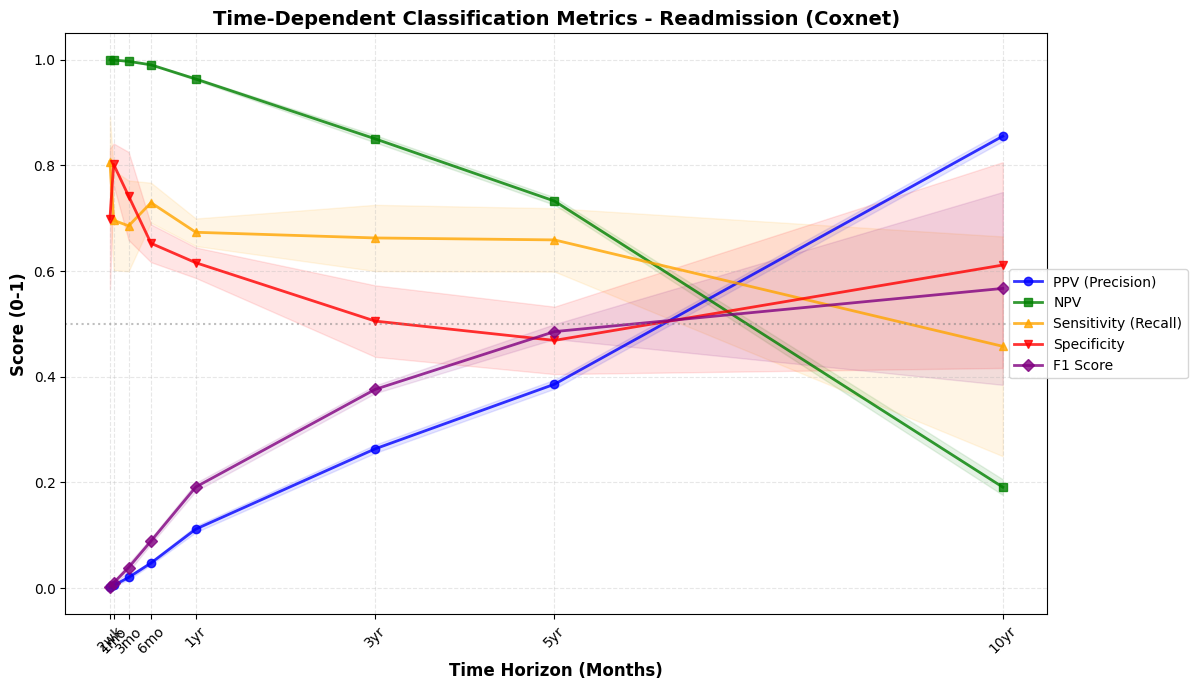

In [17]:
import time
from google.colab import data_table
data_table.enable_dataframe_formatter()

print("\n" + "🔵"*40)
print(">>> OUTCOME: READMISSION (Coxnet 10% Regularized) <<<")
print("🔵"*40 + "\n")

# Start timer
start_time = time.time()

# Run analysis (Using the updated function with PPV/NPV/F1)
df_global_readm2, df_time_readm2, df_imp_readm2 = permutation_importance_timespecific_cv_mi(
    X_list=imputations_list_jan26,
    y_surv_list=y_surv_readm_list_corrected,
    times_eval=times_eval_grid,
    alpha_idx=49,   # Least regularization (Standard Cox behavior mostly)
    n_splits=5,
    n_repeats=20,
    random_state=2125,
    l1_ratio=0.1,       # More Ridge-like
    alpha_min_ratio=0.01,
    n_alphas=50,
    max_iter=100000,
    n_jobs=-1
)

# End timer
end_time = time.time()
elapsed = end_time - start_time
print(f"Process completed in {elapsed/60:.2f} minutes")

# --- DISPLAY RESULTS ---

print("\n" + "="*80)
print("DETAILED GLOBAL METRICS")
print("="*80)
display(df_global_readm2)

print("\n" + "="*80)
print("DETAILED TIME-SPECIFIC PERFORMANCE (Includes PPV, NPV, F1)")
print("="*80)
# Mostrar columnas clave
cols_view = ['time_label', 'auc_mean', 'bs_mean', 'ppv_mean', 'npv_mean', 'sens_mean', 'f1_mean']
display(df_time_readm2[cols_view])

print("\n" + "="*80)
print("TOP 20 FEATURES (Permutation Importance)")
print("="*80)

styled_table = df_imp_readm2.head(20).style \
    .background_gradient(subset=['mean_drop_cindex'], cmap='Blues') \
    .format({'mean_drop_cindex': "{:.5f}", 'sd_drop_cindex': "{:.5f}"}) \
    .set_properties(**{'text-align': 'left', 'font-family': 'Arial'})

display(styled_table)

# --- VISUALIZATION ---
print("\n>>> VISUALIZATION: CLASSIFICATION METRICS OVER TIME <<<")
plot_time_dependent_classification_metrics(df_time_readm2, outcome_name="Readmission (Coxnet)")


🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵
>>> OUTCOME: MORTALITY (Coxnet 10% Regularized) <<<
🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵


TIME-SPECIFIC PERFORMANCE EVALUATION (Updated with Classification Metrics)
Imputations: 5, CV folds: 10
Time points: 8


>>> GLOBAL METRICS <<<
C-index:       0.7106 ± 0.0174

>>> TIME-SPECIFIC METRICS (Classification) <<<
time_label  auc_mean  bs_mean  ppv_mean  npv_mean  f1_mean
       2wk     0.720    0.000     0.030     1.000    0.053
       1mo     0.758    0.000     0.004     1.000    0.007
       3mo     0.748    0.001     0.007     0.999    0.014
       6mo     0.725    0.003     0.009     0.999    0.018
       1yr     0.736    0.007     0.018     0.997    0.035
       3yr     0.736    0.023     0.061     0.987    0.112
       5yr     0.745    0.038     0.130     0.972    0.217
      10yr     0.745    0.069     0.656     0.773    0.648
Process completed in 18.00 minutes

>>> TIME-SPECIFIC PERFORMANCE (Mortality) <<<


,time_label,auc_mean,bs_mean,ppv_mean,npv_mean,f1_mean
0,2wk,0.720098,0.000124,0.030127,0.999961,0.052636
1,1mo,0.758296,0.000328,0.003590,0.999953,0.007092
2,3mo,0.747555,0.001428,0.007045,0.999488,0.013794
3,6mo,0.724674,0.003483,0.009421,0.998538,0.018495
4,1yr,0.735512,0.007036,0.017904,0.996840,0.034787
5,3yr,0.735603,0.022802,0.061393,0.987067,0.112325
6,5yr,0.745161,0.037846,0.129778,0.972484,0.216832
7,10yr,0.744511,0.069244,0.655730,0.772558,0.647743



>>> TOP 20 FEATURES (Mortality) <<<


,feature,mean_drop_cindex,sd_drop_cindex
0,adm_age_rec3,0.19297,0.02683
1,primary_sub_mod_alcohol,0.00365,0.00146
2,eva_ocupacion,0.00352,0.00216
3,prim_sub_freq_rec,0.00190,0.00143
4,eva_fisica,0.00149,0.00175
5,dit_m,0.00121,0.00460
6,tenure_status_household,0.00098,0.00185
7,cohabitation_with_couple_children,0.00055,0.00046
8,eva_sm,0.00031,0.00062
9,any_phys_dx,0.00015,0.00013



>>> VISUALIZATION: CLASSIFICATION METRICS OVER TIME <<<


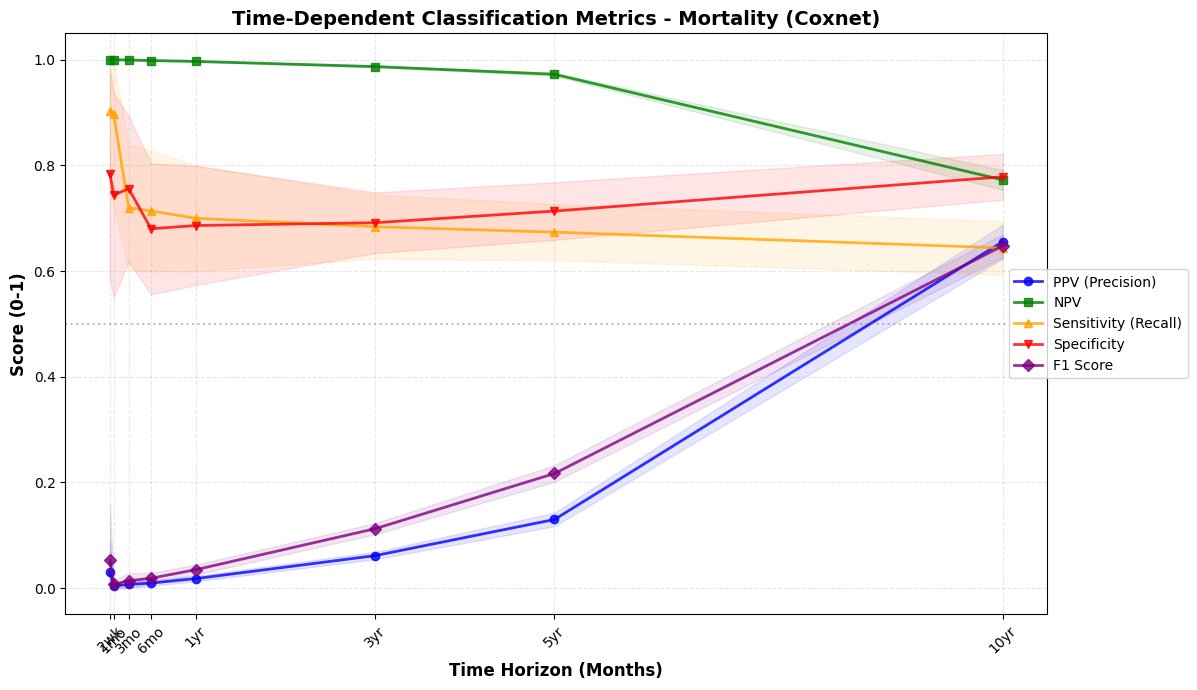

In [18]:
print("\n" + "🔵"*40)
print(">>> OUTCOME: MORTALITY (Coxnet 10% Regularized) <<<")
print("🔵"*40 + "\n")

start_time = time.time()

# Run analysis
df_global_death2, df_time_death2, df_imp_death2 = permutation_importance_timespecific_cv_mi(
    X_list=imputations_list_jan26,
    y_surv_list=y_surv_death_list,
    times_eval=times_eval_grid,
    alpha_idx=49,
    n_splits=10,
    n_repeats=20,
    random_state=2125,
    l1_ratio=0.1,
    alpha_min_ratio=0.01,
    n_alphas=50,
    max_iter=100000,
    n_jobs=-1
)

end_time = time.time()
elapsed = end_time - start_time
print(f"Process completed in {elapsed/60:.2f} minutes")

# --- DISPLAY RESULTS ---
print("\n>>> TIME-SPECIFIC PERFORMANCE (Mortality) <<<")
cols_view = ['time_label', 'auc_mean', 'bs_mean', 'ppv_mean', 'npv_mean', 'f1_mean']
display(df_time_death2[cols_view])

print("\n>>> TOP 20 FEATURES (Mortality) <<<")
styled_table_death = df_imp_death2.head(20).style \
    .background_gradient(subset=['mean_drop_cindex'], cmap='Reds') \
    .format({'mean_drop_cindex': "{:.5f}", 'sd_drop_cindex': "{:.5f}"})
display(styled_table_death)

# --- VISUALIZATION ---
print("\n>>> VISUALIZATION: CLASSIFICATION METRICS OVER TIME <<<")
plot_time_dependent_classification_metrics(df_time_death2, outcome_name="Mortality (Coxnet)")

# 2. Model Evaluation: Discrimination (C-index) vs. Null Baseline
After evaluating the Integrated Brier Score (IBS), which measures the accuracy of the predicted survival probabilities (calibration), we now evaluate the Discrimination of the model.

A model that knows nothing (Null) is always equivalent to a random coin toss, regardless of how many people die.


In [19]:
import numpy as np
import pandas as pd
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.functions import StepFunction
from sklearn.metrics import confusion_matrix, f1_score, roc_curve

def get_binary_metrics(y_true, y_pred):
    """
    Helper function to calculate standard binary classification metrics.
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    # Avoid division by zero
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    ppv  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    npv  = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    f1   = f1_score(y_true, y_pred, zero_division=0)

    return {'Sens': sens, 'Spec': spec, 'PPV': ppv, 'NPV': npv, 'F1': f1}

def compare_model_vs_null(y_train, y_test, model_risk_scores, time_points):
    """
    Compares your trained model against a Null (Kaplan-Meier Baseline) model.

    Logic:
    - Null Model: Predicts class based on population average.
      If >50% of people die by time t, predict Death for ALL. Otherwise, predict Survival for ALL.
    - Your Model: Uses Youden's J statistic (Sens + Spec - 1) to find the optimal cut-off
      for risk scores at each time point.
    """

    # 1. Train Kaplan-Meier (Null Baseline) on Training Data
    # We use training data to avoid data leakage.
    times_km, surv_km = kaplan_meier_estimator(y_train['event'], y_train['time'])
    km_predict_fn = StepFunction(times_km, surv_km) # Function to get S(t)

    results_list = []

    print(f"{'Time':<10} | {'Model F1':<10} | {'Null F1':<10} | {'F1 Gain':<10} | {'Model Sens':<10}")
    print("-" * 65)

    for t in time_points:
        # --- A. Define Ground Truth at time t ---
        # We only evaluate patients who are either:
        # 1. Dead/Readmitted by time t (Case = 1)
        # 2. Known to survive past time t (Control = 0)
        # Censored patients before time t are excluded (unknown status)
        is_case = (y_test['event'] == True) & (y_test['time'] <= t)
        is_control = (y_test['time'] > t)
        valid_mask = is_case | is_control

        if valid_mask.sum() < 10: # Skip if too few samples
            continue

        y_true_binary = is_case[valid_mask].astype(int)
        current_scores = model_risk_scores[valid_mask]

        # --- B. Evaluate YOUR MODEL (Smart) ---
        # 1. Find optimal threshold using ROC curve (Youden's Index)
        # This ensures we are fair to the model by picking its best operating point
        fpr, tpr, thresholds = roc_curve(y_true_binary, current_scores)
        optimal_idx = np.argmax(tpr - fpr)
        best_threshold = thresholds[optimal_idx]

        # 2. Make predictions
        y_pred_model = (current_scores >= best_threshold).astype(int)
        metrics_model = get_binary_metrics(y_true_binary, y_pred_model)

        # --- C. Evaluate NULL MODEL (Naive) ---
        # 1. Get population probability of event at time t
        prob_survival_population = km_predict_fn(t)
        prob_event_population = 1.0 - prob_survival_population

        # 2. Decision Rule: Majority Vote
        # If Prob(Event) > 0.5, predict 1 for everyone. Else predict 0 for everyone.
        null_prediction_class = 1 if prob_event_population >= 0.5 else 0
        y_pred_null = np.full(len(y_true_binary), null_prediction_class)

        metrics_null = get_binary_metrics(y_true_binary, y_pred_null)

        # --- D. Store Results ---
        row = {'Time_Month': t}

        # Save absolute metrics
        for k in metrics_model:
            row[f'{k}_Model'] = metrics_model[k]
            row[f'{k}_Null'] = metrics_null[k]
            row[f'{k}_Gain'] = metrics_model[k] - metrics_null[k] # Positive = Model is better

        results_list.append(row)

        # Print quick progress
        print(f"{t:<10.1f} | {metrics_model['F1']:<10.3f} | {metrics_null['F1']:<10.3f} | {metrics_model['F1'] - metrics_null['F1']:<10.3f} | {metrics_model['Sens']:<10.3f}")

    return pd.DataFrame(results_list)


### Readmission

In [20]:
from sksurv.metrics import concordance_index_censored
import numpy as np

# 1. Your Model's Performance
model_c_index_readm = 0.6117

# 2. Calculate the Null C-index
# A Null model predicts the same risk (e.g., zero) for everyone
null_preds = np.zeros(len(y_surv_readm))

# The concordance_index_censored function will treat tied risks
# as 0.5 (random chance)
null_c_index = concordance_index_censored(
    y_surv_readm["event"],
    y_surv_readm["time"],
    null_preds
)[0]

print(f"Model C-index: {model_c_index_readm:.4f}")
print(f"Null C-index:  {null_c_index:.4f}")

# 3. Final Comparison
diff = model_c_index_readm - null_c_index

print(f"\n--- VERDICT ---")
if diff > 0.1:
    print(f"The model is significantly better than the Null baseline.")
    print(f"Improvement over KM-only approach: {diff:.4f}")
else:
    print(f"The model is barely outperforming the Null baseline.")

Model C-index: 0.6117
Null C-index:  0.5000

--- VERDICT ---
The model is significantly better than the Null baseline.
Improvement over KM-only approach: 0.1117


In [22]:
from sklearn.model_selection import train_test_split
from sksurv.linear_model import CoxnetSurvivalAnalysis # Probablemente también necesites esta si no la cargaste antes

print("\n" + "🔵"*30)
print(">>> READMISSION: MODEL vs NULL COMPARISON")
print("🔵"*30)

# 1. Prepare Data (Using Imputation 0)
X = imputations_list_jan26[0]
y = y_surv_readm_list_corrected[0]

# 2. Split (80/20) to generate valid test predictions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y['event'], random_state=2125
)

# 3. Fit Model (Coxnet) to get Risk Scores
# We use the parameters you specified earlier (l1_ratio=0.1)
cox_readm = CoxnetSurvivalAnalysis(
    l1_ratio=0.1, alpha_min_ratio=0.01, n_alphas=50, fit_baseline_model=True
)
cox_readm.fit(X_train, y_train)

# Predict Risk Scores on Test Set
scores_readm = cox_readm.predict(X_test)

# 4. Run Comparison
df_readm_comp = compare_model_vs_null(
    y_train, y_test, scores_readm, times_eval_grid
)

# 5. Display
cols = ['Time_Month', 'F1_Model', 'F1_Null', 'F1_Gain', 'PPV_Model', 'NPV_Model']
display(df_readm_comp[cols].round(3))

# Quick Check
if df_readm_comp['F1_Gain'].mean() > 0:
    print("✅ Verdict: Model beats the Null baseline (Positive F1 Gain).")
else:
    print("⚠️ Verdict: Model is struggling to beat the baseline.")


🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵
>>> READMISSION: MODEL vs NULL COMPARISON
🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵
Time       | Model F1   | Null F1    | F1 Gain    | Model Sens
-----------------------------------------------------------------
0.5        | 0.002      | 0.000      | 0.002      | 1.000     
1.0        | 0.010      | 0.000      | 0.010      | 0.696     
3.0        | 0.030      | 0.000      | 0.030      | 0.739     
6.0        | 0.095      | 0.000      | 0.095      | 0.693     
12.0       | 0.185      | 0.000      | 0.185      | 0.683     
36.0       | 0.374      | 0.000      | 0.374      | 0.587     
60.0       | 0.451      | 0.000      | 0.451      | 0.505     
120.0      | 0.769      | 0.000      | 0.769      | 0.700     


,Time_Month,F1_Model,F1_Null,F1_Gain,PPV_Model,NPV_Model
0,0.5,0.002,0.0,0.002,0.001,1.000
1,1.0,0.010,0.0,0.010,0.005,1.000
2,3.0,0.030,0.0,0.030,0.015,0.997
3,6.0,0.095,0.0,0.095,0.051,0.989
4,12.0,0.185,0.0,0.185,0.107,0.964
5,36.0,0.374,0.0,0.374,0.274,0.846
6,60.0,0.451,0.0,0.451,0.408,0.722
7,120.0,0.769,0.0,0.769,0.852,0.201


✅ Verdict: Model beats the Null baseline (Positive F1 Gain).


### Death

In [23]:
from sksurv.metrics import concordance_index_censored
import numpy as np

# 1. Get your model's risk scores (Higher score = higher risk of event)
# Assuming 'preds_model' contains the risk scores from your actual model
# preds_model = model.predict(X_test)
c_index_model = 0.7106  # Placeholder for your actual model's C-index

# 2. Create the "Null Prediction" (Same risk for everyone)
null_preds = np.zeros(len(y_surv_death))

# 3. Calculate C-index for the Null Model
# Returns a tuple: (c-index, concordant, discordant, tied_risk, tied_time)
null_c_index = concordance_index_censored(
    y_surv_death["event"],
    y_surv_death["time"],
    null_preds
)[0]

print(f"Model C-index: {c_index_model:.4f}")
print(f"Null C-index:  {null_c_index:.4f}")

# 4. Evaluation Logic
diff = c_index_model - null_c_index

if diff < 0.02:
    print(f"\nCONCLUSION: The model has almost no discriminative power.")
    print(f"It performs similarly to a random guess (0.5).")
elif diff < 0.10:
    print(f"\nCONCLUSION: The model shows slight discrimination ({diff:.4f} above chance),")
    print("but it is likely too weak for clinical decision-making.")
else:
    print(f"\nCONCLUSION: The model is successfully ranking patient risks.")

Model C-index: 0.7106
Null C-index:  0.5000

CONCLUSION: The model is successfully ranking patient risks.


In [24]:
from sklearn.model_selection import train_test_split
from sksurv.linear_model import CoxnetSurvivalAnalysis # Probablemente también necesites esta si no la cargaste antes

print("\n" + "🔵"*30)
print(">>> MORTALITY: MODEL vs NULL COMPARISON")
print("🔵"*30)

# 1. Prepare Data (Using Imputation 0)
X = imputations_list_jan26[0]
y = y_surv_death_list[0] # <--- Changed to Death

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y['event'], random_state=2125
)

# 3. Fit Model
cox_death = CoxnetSurvivalAnalysis(
    l1_ratio=0.1, alpha_min_ratio=0.01, n_alphas=50, fit_baseline_model=True
)
cox_death.fit(X_train, y_train)

# Predict Risk Scores
scores_death = cox_death.predict(X_test)

# 4. Run Comparison
df_death_comp = compare_model_vs_null(
    y_train, y_test, scores_death, times_eval_grid
)

# 5. Display
cols = ['Time_Month', 'F1_Model', 'F1_Null', 'F1_Gain', 'PPV_Model', 'NPV_Model']
display(df_death_comp[cols].round(3))

if df_death_comp['F1_Gain'].mean() > 0.1:
    print("✅ Verdict: Strong performance gain over Null baseline.")


🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵
>>> MORTALITY: MODEL vs NULL COMPARISON
🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵
Time       | Model F1   | Null F1    | F1 Gain    | Model Sens
-----------------------------------------------------------------
0.5        | 0.000      | 0.000      | 0.000      | 1.000     
1.0        | 0.001      | 0.000      | 0.001      | 1.000     
3.0        | 0.006      | 0.000      | 0.006      | 0.920     
6.0        | 0.012      | 0.000      | 0.012      | 0.673     
12.0       | 0.025      | 0.000      | 0.025      | 0.684     
36.0       | 0.097      | 0.000      | 0.097      | 0.698     
60.0       | 0.207      | 0.000      | 0.207      | 0.653     
120.0      | 0.646      | 0.000      | 0.646      | 0.648     


,Time_Month,F1_Model,F1_Null,F1_Gain,PPV_Model,NPV_Model
0,0.5,0.000,0.0,0.000,0.000,1.000
1,1.0,0.001,0.0,0.001,0.001,1.000
2,3.0,0.006,0.0,0.006,0.003,1.000
3,6.0,0.012,0.0,0.012,0.006,0.998
4,12.0,0.025,0.0,0.025,0.013,0.997
5,36.0,0.097,0.0,0.097,0.052,0.988
6,60.0,0.207,0.0,0.207,0.123,0.972
7,120.0,0.646,0.0,0.646,0.643,0.777


✅ Verdict: Strong performance gain over Null baseline.
